# Article Lifecycle Analysis

**Paper 2: Cross-Code Comparative Analysis - Part 9**

This notebook analyzes the lifecycle of individual articles across historical versions:

1. **Article Tracking**: Track article additions and deletions across versions
2. **Lifecycle Events**: Build timeline of article lifecycle events
3. **Stability Analysis**: Identify most stable vs volatile articles
4. **Lifespan Metrics**: Calculate article lifespan and survival rates
5. **Cross-Code Comparison**: Compare article stability across codes

**Data Source**: Version data from notebook 08 (`output/08/`) and raw history files

**Key Questions**:
- Which articles have existed since the beginning vs recently added?
- Which articles were deleted/excluded over time?
- What is the average article lifespan?
- Which code has the most stable/volatile articles?

**Important**: This analysis tracks articles by their **article number** (e.g., "Статья 408") rather than internal ID (e.g., "z1497"). Internal IDs can change between versions even when the article content remains the same, which would cause false positives for additions/deletions.

## 1. Setup and Imports

In [38]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

# Data paths
HISTORY_PATH = Path("../data/raw/by_history")
OUTPUT_08 = Path("../output/08")
OUTPUT_DIR = Path("../output/09")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"History data path: {HISTORY_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Setup complete!
History data path: ../data/raw/by_history
Output directory: ../output/09


## 2. Load Code Metadata and Version Index

In [39]:
# Load consolidated index from notebook 08
with open(OUTPUT_08 / 'consolidated_version_index.json', 'r', encoding='utf-8') as f:
    version_index = json.load(f)

# Code metadata
CODES = {
    "criminal": {
        "folder": "K1400000226_rus_ugolov",
        "name_ru": "Уголовный кодекс",
        "name_en": "Criminal Code",
        "short": "УК",
        "color": "#e74c3c"
    },
    "administrative": {
        "folder": "K1400000235_rus_adm",
        "name_ru": "Кодекс об административных правонарушениях",
        "name_en": "Administrative Code",
        "short": "КоАП",
        "color": "#3498db"
    },
    "civil": {
        "folder": "K940001000__rus_grazh",
        "name_ru": "Гражданский кодекс",
        "name_en": "Civil Code",
        "short": "ГК",
        "color": "#2ecc71"
    },
    "labor": {
        "folder": "K1500000414_rus_trud",
        "name_ru": "Трудовой кодекс",
        "name_en": "Labor Code",
        "short": "ТК",
        "color": "#f39c12"
    },
    "tax": {
        "folder": "K2500000214_rus_nalog",
        "name_ru": "Налоговый кодекс",
        "name_en": "Tax Code",
        "short": "НК",
        "color": "#9b59b6"
    }
}

print("Version Index Summary:")
print(f"Total versions: {version_index['total_versions']}")
print(f"Date range: {version_index['date_range']['earliest']} to {version_index['date_range']['latest']}")
print("\nVersions per code:")
for code_key, code_data in version_index['codes'].items():
    print(f"  {code_data['short']:6}: {code_data['total_versions']:3} versions")

Version Index Summary:
Total versions: 563
Date range: 1996-07-15 to 2025-12-17

Versions per code:
  УК    : 109 versions
  КоАП  : 205 versions
  ГК    : 179 versions
  ТК    :  69 versions
  НК    :   1 versions


## 3. Load All Versions and Extract Article IDs

In [40]:
import re
import hashlib

def load_version_file(code_folder, filename):
    """Load a specific version file."""
    filepath = HISTORY_PATH / code_folder / filename
    if filepath.exists():
        with open(filepath, 'r', encoding='utf-8') as f:
            return json.load(f)
    return None

def extract_article_number(title):
    """
    Extract article number from title like 'Статья 408. ...' -> '408'
    Also handles 'Статья 408-1.' -> '408-1'
    """
    if not title:
        return None
    match = re.search(r'Статья\s+([\d]+-?\d*)', title)
    if match:
        return match.group(1)
    return None

def normalize_text(text):
    """Normalize text for comparison: lowercase, remove extra whitespace."""
    if not text:
        return ""
    # Lowercase and normalize whitespace
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def text_hash(text):
    """Generate hash of normalized text for fast comparison."""
    normalized = normalize_text(text)
    return hashlib.md5(normalized.encode('utf-8')).hexdigest()

def tokenize_russian(text):
    """Simple tokenization for Russian text."""
    text = normalize_text(text)
    # Keep only words (Cyrillic and Latin letters, numbers)
    tokens = re.findall(r'[а-яёa-z0-9]+', text)
    return set(tokens)

def jaccard_similarity(text1, text2):
    """Calculate Jaccard similarity between two texts."""
    tokens1 = tokenize_russian(text1)
    tokens2 = tokenize_russian(text2)
    
    if not tokens1 and not tokens2:
        return 1.0
    if not tokens1 or not tokens2:
        return 0.0
    
    intersection = tokens1 & tokens2
    union = tokens1 | tokens2
    
    return len(intersection) / len(union)

def is_article_excluded(article_data):
    """
    Check if article has been excluded/deleted.
    An excluded article has empty article_text but contains notes with deletion info.
    
    Returns: (is_excluded: bool, deletion_reason: str or None)
    """
    text = article_data.get('article_text', '') or ''
    notes = article_data.get('notes', [])
    
    # If text is not empty, article is not excluded
    if text.strip():
        return False, None
    
    # If no notes, we can't determine if it's excluded
    if not notes:
        return False, None
    
    # Check notes for exclusion keywords
    for note in notes:
        note_text = note.get('text', '') if isinstance(note, dict) else str(note)
        note_lower = note_text.lower()
        
        # Look for exclusion keywords
        if 'исключен' in note_lower or 'утратил силу' in note_lower:
            return True, note_text
    
    return False, None

def extract_deletion_reason(notes):
    """
    Extract the deletion/exclusion reason from article notes.
    Returns the first note that mentions exclusion, or None.
    """
    if not notes:
        return None
    
    for note in notes:
        note_text = note.get('text', '') if isinstance(note, dict) else str(note)
        note_lower = note_text.lower()
        
        if 'исключен' in note_lower or 'утратил силу' in note_lower:
            return note_text
    
    return None

def extract_articles_by_number(version_data):
    """
    Extract articles keyed by article NUMBER (not internal ID).
    Returns dict: article_number -> {id, title, text, text_hash, is_excluded, deletion_reason, notes}
    
    IMPORTANT: When article_text is empty but notes exist with exclusion info,
    the article is marked as excluded. This is important for similarity analysis
    to distinguish between "deleted" (excluded) articles and actual content changes.
    """
    if not version_data or 'articles' not in version_data:
        return {}
    
    result = {}
    for art in version_data['articles']:
        title = art.get('article_title', '')
        art_num = extract_article_number(title)
        if art_num:
            full_text = art.get('article_text', '') or ''
            notes = art.get('notes', [])
            is_excluded, deletion_reason = is_article_excluded(art)
            
            result[art_num] = {
                'id': art['article_id'],
                'title': title,
                'text': full_text,  # Full text for similarity calculation
                'text_hash': text_hash(full_text),  # Hash for fast change detection
                'is_excluded': is_excluded,  # True if article was excluded/deleted
                'deletion_reason': deletion_reason,  # The exclusion note if available
                'notes': notes  # All notes for reference
            }
    return result

def parse_version_date(date_str):
    """Parse version date from DD.MM.YYYY format."""
    try:
        return datetime.strptime(date_str, "%d.%m.%Y")
    except:
        return None

# Test functions
test_text1 = "Статья 1. Гражданским законодательством регулируются товарно-денежные отношения."
test_text2 = "Статья 1. Гражданским законодательством регулируются товарно-денежные и иные отношения."
test_text3 = "Статья 1. Гражданским  законодательством   регулируются товарно-денежные отношения."  # Extra whitespace

print("Update detection improvements:")
print("-" * 60)
print(f"Hash comparison (fast change detection):")
print(f"  text1 hash: {text_hash(test_text1)[:16]}...")
print(f"  text2 hash: {text_hash(test_text2)[:16]}...")
print(f"  text3 hash: {text_hash(test_text3)[:16]}... (same as text1 - whitespace normalized)")
print(f"\nJaccard similarity:")
print(f"  text1 vs text2: {jaccard_similarity(test_text1, test_text2):.3f} (minor change)")
print(f"  text1 vs text3: {jaccard_similarity(test_text1, test_text3):.3f} (identical after normalization)")

# Test exclusion detection
print(f"\nExclusion detection:")
test_excluded_article = {
    'article_text': '',
    'notes': [{'text': 'Статья 197 исключена Законом РК от 24.05.2018 № 156-VI'}]
}
test_normal_article = {
    'article_text': 'Some text content',
    'notes': []
}
is_excl, reason = is_article_excluded(test_excluded_article)
print(f"  Excluded article detected: {is_excl}")
print(f"  Deletion reason: {reason[:50]}..." if reason else "  No reason")
is_excl2, _ = is_article_excluded(test_normal_article)
print(f"  Normal article excluded: {is_excl2}")

Update detection improvements:
------------------------------------------------------------
Hash comparison (fast change detection):
  text1 hash: 3176d489449abe35...
  text2 hash: bc500fcbd5fdb0b8...
  text3 hash: 3176d489449abe35... (same as text1 - whitespace normalized)

Jaccard similarity:
  text1 vs text2: 0.800 (minor change)
  text1 vs text3: 1.000 (identical after normalization)

Exclusion detection:
  Excluded article detected: True
  Deletion reason: Статья 197 исключена Законом РК от 24.05.2018 № 15...
  Normal article excluded: False


In [41]:
# Load version indices for all codes
def load_version_index(code_key):
    """Load version index for a specific code."""
    folder = CODES[code_key]["folder"]
    index_path = HISTORY_PATH / folder / "versions_index.json"
    
    if not index_path.exists():
        print(f"Warning: No index found for {code_key}")
        return None
    
    with open(index_path, 'r', encoding='utf-8') as f:
        return json.load(f)

# Load all version indices
all_indices = {}
for code_key in CODES.keys():
    index_data = load_version_index(code_key)
    if index_data:
        all_indices[code_key] = index_data
        print(f"{CODES[code_key]['short']:6} | {index_data['total_versions']:3} versions indexed")

print(f"\nTotal codes loaded: {len(all_indices)}")

УК     | 109 versions indexed
КоАП   | 205 versions indexed
ГК     | 179 versions indexed
ТК     |  69 versions indexed
НК     |   1 versions indexed

Total codes loaded: 5


## 4. Track Article Lifecycle Events

In [42]:
def analyze_article_lifecycle(code_key):
    """
    Analyze article lifecycle for a specific code.
    
    IMPORTANT: Tracks by ARTICLE NUMBER (e.g., "408") not internal ID (e.g., "z1497").
    Internal IDs can change between versions even when the article itself remains.
    
    Events tracked:
    - initial: article exists in first version
    - added: new article number appears
    - deleted: article number disappears from versions entirely
    - excluded: article text becomes empty (article excluded by law, only note remains)
    - updated: article text changed (detected via hash of full normalized text)
    
    Update detection:
    - Uses MD5 hash of normalized full text for fast change detection
    - Calculates Jaccard similarity to quantify change magnitude
    - Ignores whitespace-only changes
    - SKIPS similarity calculation for excluded articles (similarity = None)
    
    Returns:
    - lifecycle_events: list of events with similarity scores for updates
    - article_lifespans: dict of article_number -> metrics
    """
    code_info = CODES[code_key]
    index_data = all_indices.get(code_key)
    
    if not index_data:
        return [], {}
    
    versions = index_data['versions']
    lifecycle_events = []
    article_lifespans = defaultdict(lambda: {
        'first_seen': None,
        'last_seen': None,
        'first_title': '',
        'last_title': '',
        'versions_present': 0,
        'update_count': 0,
        'total_change_magnitude': 0.0,  # Sum of (1 - similarity) for all updates
        'is_excluded': False,  # True if article was excluded (not just deleted)
        'exclusion_date': None,  # When article was excluded
        'exclusion_reason': None  # The legal reason for exclusion
    })
    
    prev_article_numbers = set()
    prev_articles = {}  # article_number -> {id, title, text, text_hash, is_excluded, ...}
    all_article_titles = {}
    final_article_numbers = set()
    
    for i, version in enumerate(versions):
        version_date = parse_version_date(version['version_date'])
        version_data = load_version_file(code_info['folder'], version['filename'])
        
        if not version_data:
            continue
        
        # Extract articles by NUMBER (now includes full text, hash, and exclusion info)
        current_articles = extract_articles_by_number(version_data)
        current_article_numbers = set(current_articles.keys())
        
        # Update title mapping
        for art_num, art_info in current_articles.items():
            all_article_titles[art_num] = art_info['title']
        
        # First version - all articles are "initial"
        if i == 0:
            for art_num in current_article_numbers:
                art_info = current_articles[art_num]
                # Check if article is already excluded in first version
                if art_info.get('is_excluded'):
                    lifecycle_events.append({
                        'date': version_date,
                        'event': 'initial_excluded',
                        'article_number': art_num,
                        'article_title': art_info['title'],
                        'version_number': version['version_number'],
                        'similarity': None,
                        'deletion_reason': art_info.get('deletion_reason')
                    })
                    article_lifespans[art_num]['is_excluded'] = True
                    article_lifespans[art_num]['exclusion_reason'] = art_info.get('deletion_reason')
                else:
                    lifecycle_events.append({
                        'date': version_date,
                        'event': 'initial',
                        'article_number': art_num,
                        'article_title': art_info['title'],
                        'version_number': version['version_number'],
                        'similarity': None,
                        'deletion_reason': None
                    })
                article_lifespans[art_num]['first_seen'] = version_date
                article_lifespans[art_num]['first_title'] = art_info['title']
        else:
            # Find added articles (new article numbers)
            added = current_article_numbers - prev_article_numbers
            for art_num in added:
                art_info = current_articles[art_num]
                lifecycle_events.append({
                    'date': version_date,
                    'event': 'added',
                    'article_number': art_num,
                    'article_title': art_info['title'],
                    'version_number': version['version_number'],
                    'similarity': None,
                    'deletion_reason': None
                })
                if article_lifespans[art_num]['first_seen'] is None:
                    article_lifespans[art_num]['first_seen'] = version_date
                    article_lifespans[art_num]['first_title'] = art_info['title']
            
            # Find deleted articles (removed article numbers entirely)
            deleted = prev_article_numbers - current_article_numbers
            for art_num in deleted:
                lifecycle_events.append({
                    'date': version_date,
                    'event': 'deleted',
                    'article_number': art_num,
                    'article_title': all_article_titles.get(art_num, ''),
                    'version_number': version['version_number'],
                    'similarity': None,
                    'deletion_reason': None
                })
            
            # Find updated/excluded articles using hash comparison
            continuing = current_article_numbers & prev_article_numbers
            for art_num in continuing:
                prev_info = prev_articles.get(art_num, {})
                curr_info = current_articles[art_num]
                
                prev_hash = prev_info.get('text_hash', '')
                curr_hash = curr_info.get('text_hash', '')
                
                prev_excluded = prev_info.get('is_excluded', False)
                curr_excluded = curr_info.get('is_excluded', False)
                
                # Check if article became excluded (transition from content -> empty with note)
                if not prev_excluded and curr_excluded:
                    # Article was excluded in this version
                    lifecycle_events.append({
                        'date': version_date,
                        'event': 'excluded',
                        'article_number': art_num,
                        'article_title': curr_info['title'],
                        'version_number': version['version_number'],
                        'similarity': None,  # Don't calculate similarity for exclusions
                        'deletion_reason': curr_info.get('deletion_reason')
                    })
                    article_lifespans[art_num]['is_excluded'] = True
                    article_lifespans[art_num]['exclusion_date'] = version_date
                    article_lifespans[art_num]['exclusion_reason'] = curr_info.get('deletion_reason')
                    # Don't count as update
                    
                elif prev_hash != curr_hash:
                    # Normal content change (both have content, or other transitions)
                    prev_text = prev_info.get('text', '')
                    curr_text = curr_info.get('text', '')
                    
                    # Only calculate similarity if both have actual content
                    if prev_text.strip() and curr_text.strip():
                        similarity = jaccard_similarity(prev_text, curr_text)
                        article_lifespans[art_num]['update_count'] += 1
                        article_lifespans[art_num]['total_change_magnitude'] += (1 - similarity)
                    else:
                        # One of them is empty but not marked as excluded
                        similarity = 0.0 if (prev_text.strip() or curr_text.strip()) else None
                    
                    lifecycle_events.append({
                        'date': version_date,
                        'event': 'updated',
                        'article_number': art_num,
                        'article_title': curr_info['title'],
                        'version_number': version['version_number'],
                        'similarity': similarity,
                        'deletion_reason': None
                    })
        
        # Update last_seen, last_title and versions_present
        for art_num in current_article_numbers:
            article_lifespans[art_num]['last_seen'] = version_date
            article_lifespans[art_num]['last_title'] = current_articles[art_num]['title']
            article_lifespans[art_num]['versions_present'] += 1
        
        prev_article_numbers = current_article_numbers
        prev_articles = current_articles
        final_article_numbers = current_article_numbers.copy()
        
        # Progress indicator
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(versions)} versions...")
    
    # Set was_deleted based on presence in final version
    for art_num in article_lifespans:
        article_lifespans[art_num]['was_deleted'] = art_num not in final_article_numbers
    
    return lifecycle_events, dict(article_lifespans)

print("Lifecycle analysis function defined.")
print("UPDATE DETECTION: Full text hash comparison + Jaccard similarity scoring")
print("EXCLUSION DETECTION: Empty text + notes with 'исключен' keyword → 'excluded' event")

Lifecycle analysis function defined.
UPDATE DETECTION: Full text hash comparison + Jaccard similarity scoring
EXCLUSION DETECTION: Empty text + notes with 'исключен' keyword → 'excluded' event


In [43]:
# Analyze lifecycle for all codes (excluding НК which has only 1 version)
all_lifecycle_events = {}
all_article_lifespans = {}

for code_key, code_info in CODES.items():
    if code_key == 'tax':  # Skip tax code (only 1 version)
        continue
    
    print(f"\nAnalyzing {code_info['short']} ({code_info['name_en']})...")
    events, lifespans = analyze_article_lifecycle(code_key)
    
    all_lifecycle_events[code_key] = events
    all_article_lifespans[code_key] = lifespans
    
    # Summary
    n_initial = sum(1 for e in events if e['event'] == 'initial')
    n_initial_excluded = sum(1 for e in events if e['event'] == 'initial_excluded')
    n_added = sum(1 for e in events if e['event'] == 'added')
    n_deleted = sum(1 for e in events if e['event'] == 'deleted')
    n_excluded = sum(1 for e in events if e['event'] == 'excluded')
    n_updated = sum(1 for e in events if e['event'] == 'updated')
    
    # Update similarity stats (only for updates with valid similarity)
    update_events = [e for e in events if e['event'] == 'updated' and e['similarity'] is not None]
    if update_events:
        similarities = [e['similarity'] for e in update_events]
        mean_sim = sum(similarities) / len(similarities)
        minor = sum(1 for s in similarities if s >= 0.9)
        moderate = sum(1 for s in similarities if 0.7 <= s < 0.9)
        major = sum(1 for s in similarities if s < 0.7)
    else:
        mean_sim = 0
        minor = moderate = major = 0
    
    print(f"  Initial articles: {n_initial + n_initial_excluded}")
    print(f"  Articles added: {n_added}")
    print(f"  Articles deleted: {n_deleted}")
    print(f"  Articles excluded: {n_excluded + n_initial_excluded}")
    print(f"  Articles updated: {n_updated} (mean similarity: {mean_sim:.3f})")
    print(f"    → Minor (>=0.9): {minor} | Moderate (0.7<= and <0.9): {moderate} | Major (<0.7): {major}")
    print(f"  Unique articles tracked: {len(lifespans)}")


Analyzing УК (Criminal Code)...
  Processed 50/109 versions...
  Processed 100/109 versions...
  Initial articles: 467
  Articles added: 35
  Articles deleted: 0
  Articles excluded: 13
  Articles updated: 1230 (mean similarity: 0.926)
    → Minor (>=0.9): 939 | Moderate (0.7<= and <0.9): 238 | Major (<0.7): 53
  Unique articles tracked: 502

Analyzing КоАП (Administrative Code)...
  Processed 50/205 versions...
  Processed 100/205 versions...
  Processed 150/205 versions...
  Processed 200/205 versions...
  Initial articles: 917
  Articles added: 150
  Articles deleted: 1
  Articles excluded: 54
  Articles updated: 3554 (mean similarity: 0.868)
    → Minor (>=0.9): 1885 | Moderate (0.7<= and <0.9): 1252 | Major (<0.7): 417
  Unique articles tracked: 1066

Analyzing ГК (Civil Code)...
  Processed 50/179 versions...
  Processed 100/179 versions...
  Processed 150/179 versions...
  Initial articles: 390
  Articles added: 38
  Articles deleted: 3
  Articles excluded: 10
  Articles update

## 5. Build Lifecycle DataFrames

In [44]:
# Create events DataFrame
events_data = []
for code_key, events in all_lifecycle_events.items():
    for event in events:
        events_data.append({
            'code_key': code_key,
            'code_short': CODES[code_key]['short'],
            'date': event['date'],
            'event': event['event'],
            'article_number': event['article_number'],
            'article_title': event['article_title'],
            'version_number': event['version_number'],
            'similarity': event.get('similarity'),
            'deletion_reason': event.get('deletion_reason')  # Added for exclusion tracking
        })

events_df = pd.DataFrame(events_data)
events_df['year'] = events_df['date'].dt.year
events_df['month'] = events_df['date'].dt.month

print(f"Total lifecycle events: {len(events_df)}")
print(f"\nEvents by type:")
print(events_df['event'].value_counts())

# Show similarity statistics for updates (excluding excluded articles)
updates = events_df[events_df['event'] == 'updated']
updates_with_similarity = updates[updates['similarity'].notna()]
print(f"\nUpdate similarity statistics (Jaccard):")
print(f"  Total updates: {len(updates)}")
print(f"  Updates with similarity: {len(updates_with_similarity)}")
if len(updates_with_similarity) > 0:
    print(f"  Mean similarity: {updates_with_similarity['similarity'].mean():.3f}")
    print(f"  Median similarity: {updates_with_similarity['similarity'].median():.3f}")
    print(f"  Min similarity: {updates_with_similarity['similarity'].min():.3f} (major rewrite)")
    print(f"  Max similarity: {updates_with_similarity['similarity'].max():.3f} (minor change)")

# Show exclusion statistics
excluded = events_df[events_df['event'] == 'excluded']
initial_excluded = events_df[events_df['event'] == 'initial_excluded']
print(f"\nExclusion tracking:")
print(f"  Articles excluded during history: {len(excluded)}")
print(f"  Articles already excluded in first version: {len(initial_excluded)}")
if len(excluded) > 0:
    print(f"\n  Recent exclusions:")
    for _, row in excluded.tail(5).iterrows():
        reason = row['deletion_reason']
        reason_short = reason[:60] + '...' if reason and len(reason) > 60 else reason
        print(f"    [{row['code_short']}] Статья {row['article_number']} ({row['date'].strftime('%Y-%m-%d')})")
        if reason_short:
            print(f"        → {reason_short}")

Total lifecycle events: 10397

Events by type:
event
updated     8095
initial     1978
added        240
excluded      80
deleted        4
Name: count, dtype: int64

Update similarity statistics (Jaccard):
  Total updates: 8095
  Updates with similarity: 8095
  Mean similarity: 0.881
  Median similarity: 0.921
  Min similarity: 0.021 (major rewrite)
  Max similarity: 1.000 (minor change)

Exclusion tracking:
  Articles excluded during history: 80
  Articles already excluded in first version: 0

  Recent exclusions:
    [ГК] Статья 56 (2023-03-03)
        → Сноска. Статья 56 исключена Законом РК от 30.12.2022 № 179-V...
    [ГК] Статья 262 (2025-11-20)
        → Сноска. Статью 262 исключена Законом РК от 19.09.2025 № 219-...
    [ТК] Статья 199 (2018-05-24)
        → Сноска. Статья 199 исключена Законом РК от 24.05.2018 № 156-...
    [ТК] Статья 197 (2018-05-24)
        → Сноска. Статья 197 исключена Законом РК от 24.05.2018 № 156-...
    [ТК] Статья 117 (2023-09-03)
        → Сноска. Ст

In [45]:
events_df.head(5)

,code_key,code_short,date,event,article_number,article_title,version_number,similarity,deletion_reason,year,month
0,criminal,УК,2014-07-03,initial,43,Статья 43. Привлечение к общественным работам,1,NaN,None,2014,7
1,criminal,УК,2014-07-03,initial,170,Статья 170. Наемничество,1,NaN,None,2014,7
2,criminal,УК,2014-07-03,initial,377,Статья 377. Воспрепятствование деятельности,1,NaN,None,2014,7
3,criminal,УК,2014-07-03,initial,309,Статья 309. Организация или содержание притоно...,1,NaN,None,2014,7
4,criminal,УК,2014-07-03,initial,263,Статья 263. Создание и руководство преступным,1,NaN,None,2014,7


In [46]:
# Create lifespans DataFrame
lifespans_data = []
for code_key, lifespans in all_article_lifespans.items():
    for art_num, info in lifespans.items():
        if info['first_seen'] and info['last_seen']:
            lifespan_days = (info['last_seen'] - info['first_seen']).days
        else:
            lifespan_days = 0
        
        # Calculate average change magnitude per update
        avg_change = info['total_change_magnitude'] / info['update_count'] if info['update_count'] > 0 else 0
        
        lifespans_data.append({
            'code_key': code_key,
            'code_short': CODES[code_key]['short'],
            'article_number': art_num,
            'article_title': info['last_title'],
            'first_seen': info['first_seen'],
            'last_seen': info['last_seen'],
            'versions_present': info['versions_present'],
            'was_deleted': info['was_deleted'],
            'is_excluded': info.get('is_excluded', False),  # Article excluded by law
            'exclusion_date': info.get('exclusion_date'),  # When excluded
            'exclusion_reason': info.get('exclusion_reason'),  # Legal reason
            'update_count': info['update_count'],
            'total_change_magnitude': info['total_change_magnitude'],
            'avg_change_per_update': avg_change,
            'lifespan_days': lifespan_days,
            'lifespan_years': lifespan_days / 365.25
        })

lifespans_df = pd.DataFrame(lifespans_data)

print(f"Total unique articles tracked: {len(lifespans_df)}")
print(f"\nArticles per code:")
print(lifespans_df.groupby('code_short').size())
print(f"\nTotal updates tracked: {lifespans_df['update_count'].sum()}")
print(f"Total change magnitude: {lifespans_df['total_change_magnitude'].sum():.1f}")

# Exclusion summary
excluded_articles = lifespans_df[lifespans_df['is_excluded'] == True]
print(f"\n--- Exclusion Summary ---")
print(f"Total excluded articles: {len(excluded_articles)}")
if len(excluded_articles) > 0:
    print(f"\nExcluded articles by code:")
    print(excluded_articles.groupby('code_short').size())

Total unique articles tracked: 2214

Articles per code:
code_short
ГК       425
КоАП    1066
ТК       221
УК       502
dtype: int64

Total updates tracked: 8095
Total change magnitude: 960.5

--- Exclusion Summary ---
Total excluded articles: 80

Excluded articles by code:
code_short
ГК      10
КоАП    54
ТК       3
УК      13
dtype: int64


In [47]:
# Detailed Exclusion Analysis
print("=" * 80)
print("DETAILED EXCLUSION ANALYSIS")
print("=" * 80)

# Get all excluded articles with their details
excluded_df = lifespans_df[lifespans_df['is_excluded'] == True].copy()

if len(excluded_df) > 0:
    print(f"\nTotal excluded articles: {len(excluded_df)}")
    print(f"\n{'Code':<6} {'Article':<12} {'Exclusion Date':<15} {'Reason (truncated)'}")
    print("-" * 80)
    
    for _, row in excluded_df.sort_values(['code_short', 'exclusion_date']).iterrows():
        code = row['code_short']
        art_num = row['article_number']
        exc_date = row['exclusion_date'].strftime('%Y-%m-%d') if pd.notna(row['exclusion_date']) else 'N/A'
        reason = row['exclusion_reason'] or 'No reason recorded'
        reason_short = reason[:70] + '...' if len(reason) > 70 else reason
        print(f"{code:<6} {art_num:<12} {exc_date:<15} {reason_short}")
    
    # Statistics by code
    print(f"\n{'='*80}")
    print("Exclusions by Code:")
    for code in excluded_df['code_short'].unique():
        code_excluded = excluded_df[excluded_df['code_short'] == code]
        print(f"  {code}: {len(code_excluded)} articles excluded")
        if code_excluded['exclusion_date'].notna().any():
            dates = code_excluded['exclusion_date'].dropna()
            print(f"    Date range: {dates.min().strftime('%Y-%m-%d')} to {dates.max().strftime('%Y-%m-%d')}")
else:
    print("\nNo excluded articles found in the analyzed codes.")

# Also show events where articles were excluded (from events_df)
excluded_events = events_df[events_df['event'] == 'excluded']
if len(excluded_events) > 0:
    print(f"\n{'='*80}")
    print(f"Exclusion Events Timeline ({len(excluded_events)} total):")
    print("-" * 80)
    for year in sorted(excluded_events['year'].unique()):
        year_events = excluded_events[excluded_events['year'] == year]
        print(f"  {year}: {len(year_events)} articles excluded")
        for _, evt in year_events.iterrows():
            print(f"    - [{evt['code_short']}] Статья {evt['article_number']}")

DETAILED EXCLUSION ANALYSIS

Total excluded articles: 80

Code   Article      Exclusion Date  Reason (truncated)
--------------------------------------------------------------------------------
ГК     89           2003-05-16      (Статья 89 исключена - Законом РК от 16 мая 2003 г. N 416 )
ГК     90           2003-05-16      (Статья 90 исключена - Законом РК от 16 мая 2003 г. N 416 )
ГК     135          2003-05-16      (Статья 135 исключена - Законом РК от 16 мая 2003 г. N 416 )
ГК     86           2003-05-16      (Статья 86 исключена - Законом РК от 16 мая 2003 г. N 416 )
ГК     54-1         2014-03-07      Сноска. Статья 54-1 исключена Законом РК от 07.03.2014 № 177-V (вводит...
ГК     140          2016-07-26      Сноска. Статья 140 исключена Законом РК от 11.07.1997 N 154 .
ГК     138          2016-07-26      Сноска. Статья 138 исключена Законом РК от 11.07.1997 N 154 .
ГК     137          2016-07-26      Сноска. Статья 137 исключена Законом РК от 11.07.1997 N 154 .
ГК     56        

In [48]:
# Analyze exclusion patterns by law number
import re

print("=" * 80)
print("EXCLUSION PATTERNS BY LAW")
print("=" * 80)

# Extract law numbers from exclusion reasons
def extract_law_info(reason):
    """Extract law number and date from exclusion reason text."""
    if not reason:
        return None, None
    
    # Pattern: "Законом РК от DD.MM.YYYY № XXX-V" or similar
    pattern = r'Закон\w*\s+РК\s+от\s+(\d{1,2}[.\s]\w+[.\s]\d{4}|\d{2}\.\d{2}\.\d{4})\s*[гг.]*\s*[№N]\s*(\d+[-\w]*)'
    match = re.search(pattern, reason, re.IGNORECASE)
    
    if match:
        return match.group(2), match.group(1)  # law_number, date
    return None, None

# Get exclusion events and extract law info
excluded_events = events_df[events_df['event'] == 'excluded'].copy()

law_data = []
for _, row in excluded_events.iterrows():
    law_num, law_date = extract_law_info(row.get('deletion_reason', ''))
    law_data.append({
        'code_key': row['code_key'],
        'article_number': row['article_number'],
        'exclusion_date': row['date'],
        'law_number': law_num,
        'law_date': law_date
    })

law_df = pd.DataFrame(law_data)

# Group by law number
print("\nLAWS CAUSING MOST EXCLUSIONS:")
print("-" * 80)
law_counts = law_df[law_df['law_number'].notna()].groupby('law_number').agg({
    'article_number': 'count',
    'code_key': lambda x: ', '.join(sorted(set(x))),
    'law_date': 'first'
}).rename(columns={'article_number': 'articles_excluded', 'code_key': 'codes_affected'})

law_counts = law_counts.sort_values('articles_excluded', ascending=False)
print(f"{'Law Number':<20} {'Articles':>10} {'Codes Affected':<30} {'Date'}")
print("-" * 80)
for law_num, row in law_counts.head(15).iterrows():
    codes = row['codes_affected'][:25] + '...' if len(row['codes_affected']) > 25 else row['codes_affected']
    print(f"{law_num:<20} {row['articles_excluded']:>10} {codes:<30} {row['law_date']}")

# Timeline of exclusions by year
print("\n\nEXCLUSION TIMELINE BY YEAR:")
print("-" * 80)
excluded_events['year'] = pd.to_datetime(excluded_events['date']).dt.year
yearly_exclusions = excluded_events.groupby(['year', 'code_key']).size().unstack(fill_value=0)
print(yearly_exclusions.to_string())

# Summary
print(f"\n\nTotal unique laws causing exclusions: {len(law_counts)}")
print(f"Articles excluded with identified law: {law_df['law_number'].notna().sum()}")
print(f"Articles excluded without clear law reference: {law_df['law_number'].isna().sum()}")

EXCLUSION PATTERNS BY LAW

LAWS CAUSING MOST EXCLUSIONS:
--------------------------------------------------------------------------------
Law Number             Articles Codes Affected                 Date
--------------------------------------------------------------------------------
156-VI                        9 administrative, labor          24.05.2018
300-VІ                        7 administrative                 30.12.2019
155-VIII                      6 administrative                 10.01.2025
127-VI                        5 administrative                 28.12.2017
84-VI                         5 administrative, criminal       03.07.2017
403-VI                        4 administrative                 02.01.2021
166-VI                        4 administrative                 02.07.2018
416                           4 civil                          16 мая 2003
23-VIII                       3 criminal                       12.07.2023
378-V                         3 administrative

In [49]:
# Summary statistics
print("Article Lifecycle Summary by Code:")
print("=" * 80)

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_df = lifespans_df[lifespans_df['code_key'] == code_key]
    code_events = events_df[events_df['code_key'] == code_key]
    code_info = CODES[code_key]
    
    n_initial = len(code_events[code_events['event'] == 'initial'])
    n_initial_excluded = len(code_events[code_events['event'] == 'initial_excluded'])
    n_added = len(code_events[code_events['event'] == 'added'])
    n_deleted = len(code_events[code_events['event'] == 'deleted'])
    n_excluded = len(code_events[code_events['event'] == 'excluded'])
    n_current = n_initial + n_initial_excluded + n_added - n_deleted
    
    still_active = code_df[~code_df['was_deleted']]
    deleted = code_df[code_df['was_deleted']]
    excluded = code_df[code_df['is_excluded'] == True]
    
    # Update statistics (only count updates with valid similarity)
    code_updates = code_events[code_events['event'] == 'updated']
    code_updates_valid = code_updates[code_updates['similarity'].notna()]
    n_updates = len(code_updates)
    n_updates_valid = len(code_updates_valid)
    total_magnitude = code_df['total_change_magnitude'].sum()
    
    # Categorize updates by similarity
    if n_updates_valid > 0:
        minor_updates = (code_updates_valid['similarity'] >= 0.9).sum()
        moderate_updates = ((code_updates_valid['similarity'] >= 0.7) & (code_updates_valid['similarity'] < 0.9)).sum()
        major_updates = (code_updates_valid['similarity'] < 0.7).sum()
        mean_similarity = code_updates_valid['similarity'].mean()
    else:
        minor_updates = moderate_updates = major_updates = 0
        mean_similarity = 0
    
    print(f"\n{code_info['short']} ({code_info['name_en']}):")
    print(f"  ┌─ Articles ─────────────────────────────────────")
    print(f"  │  Initial: {n_initial + n_initial_excluded} → Current: {len(still_active)}")
    print(f"  │    Added: {n_added:+d}  |  Deleted: {-n_deleted:+d}  |  Excluded: {n_excluded + n_initial_excluded}")
    print(f"  │  Average lifespan: {still_active['lifespan_years'].mean():.1f} years")
    if len(deleted) > 0:
        print(f"  │  Deleted articles: {len(deleted)} (avg lifespan: {deleted['lifespan_years'].mean():.1f} years)")
    if len(excluded) > 0:
        print(f"  │  Excluded articles: {len(excluded)} (still in document with empty content)")
    print(f"  │")
    print(f"  ├─ Updates ──────────────────────────────────────")
    print(f"  │  Total updates: {n_updates}")
    print(f"  │  Total change magnitude: {total_magnitude:.1f}")
    print(f"  │  Mean similarity: {mean_similarity:.3f}")
    print(f"  │  By category:")
    print(f"  │    Minor (≥0.9):    {minor_updates:4} ({minor_updates/n_updates_valid*100 if n_updates_valid else 0:.1f}%)")
    print(f"  │    Moderate (0.7-0.9): {moderate_updates:4} ({moderate_updates/n_updates_valid*100 if n_updates_valid else 0:.1f}%)")
    print(f"  │    Major (<0.7):    {major_updates:4} ({major_updates/n_updates_valid*100 if n_updates_valid else 0:.1f}%)")
    if n_excluded > 0:
        print(f"  │")
        print(f"  ├─ Exclusions ────────────────────────────────────")
        print(f"  │  Articles excluded during history: {n_excluded}")
        if n_initial_excluded > 0:
            print(f"  │  Already excluded in first version: {n_initial_excluded}")
    print(f"  └────────────────────────────────────────────────")

Article Lifecycle Summary by Code:

ГК (Civil Code):
  ┌─ Articles ─────────────────────────────────────
  │  Initial: 390 → Current: 425
  │    Added: +38  |  Deleted: -3  |  Excluded: 10
  │  Average lifespan: 28.6 years
  │  Excluded articles: 10 (still in document with empty content)
  │
  ├─ Updates ──────────────────────────────────────
  │  Total updates: 2726
  │  Total change magnitude: 352.7
  │  Mean similarity: 0.871
  │  By category:
  │    Minor (≥0.9):    1341 (49.2%)
  │    Moderate (0.7-0.9): 1150 (42.2%)
  │    Major (<0.7):     235 (8.6%)
  │
  ├─ Exclusions ────────────────────────────────────
  │  Articles excluded during history: 10
  └────────────────────────────────────────────────

УК (Criminal Code):
  ┌─ Articles ─────────────────────────────────────
  │  Initial: 467 → Current: 502
  │    Added: +35  |  Deleted: +0  |  Excluded: 13
  │  Average lifespan: 10.6 years
  │  Excluded articles: 13 (still in document with empty content)
  │
  ├─ Updates ───────────

## 6. Visualize Article Additions, Deletions and Updates Over Time

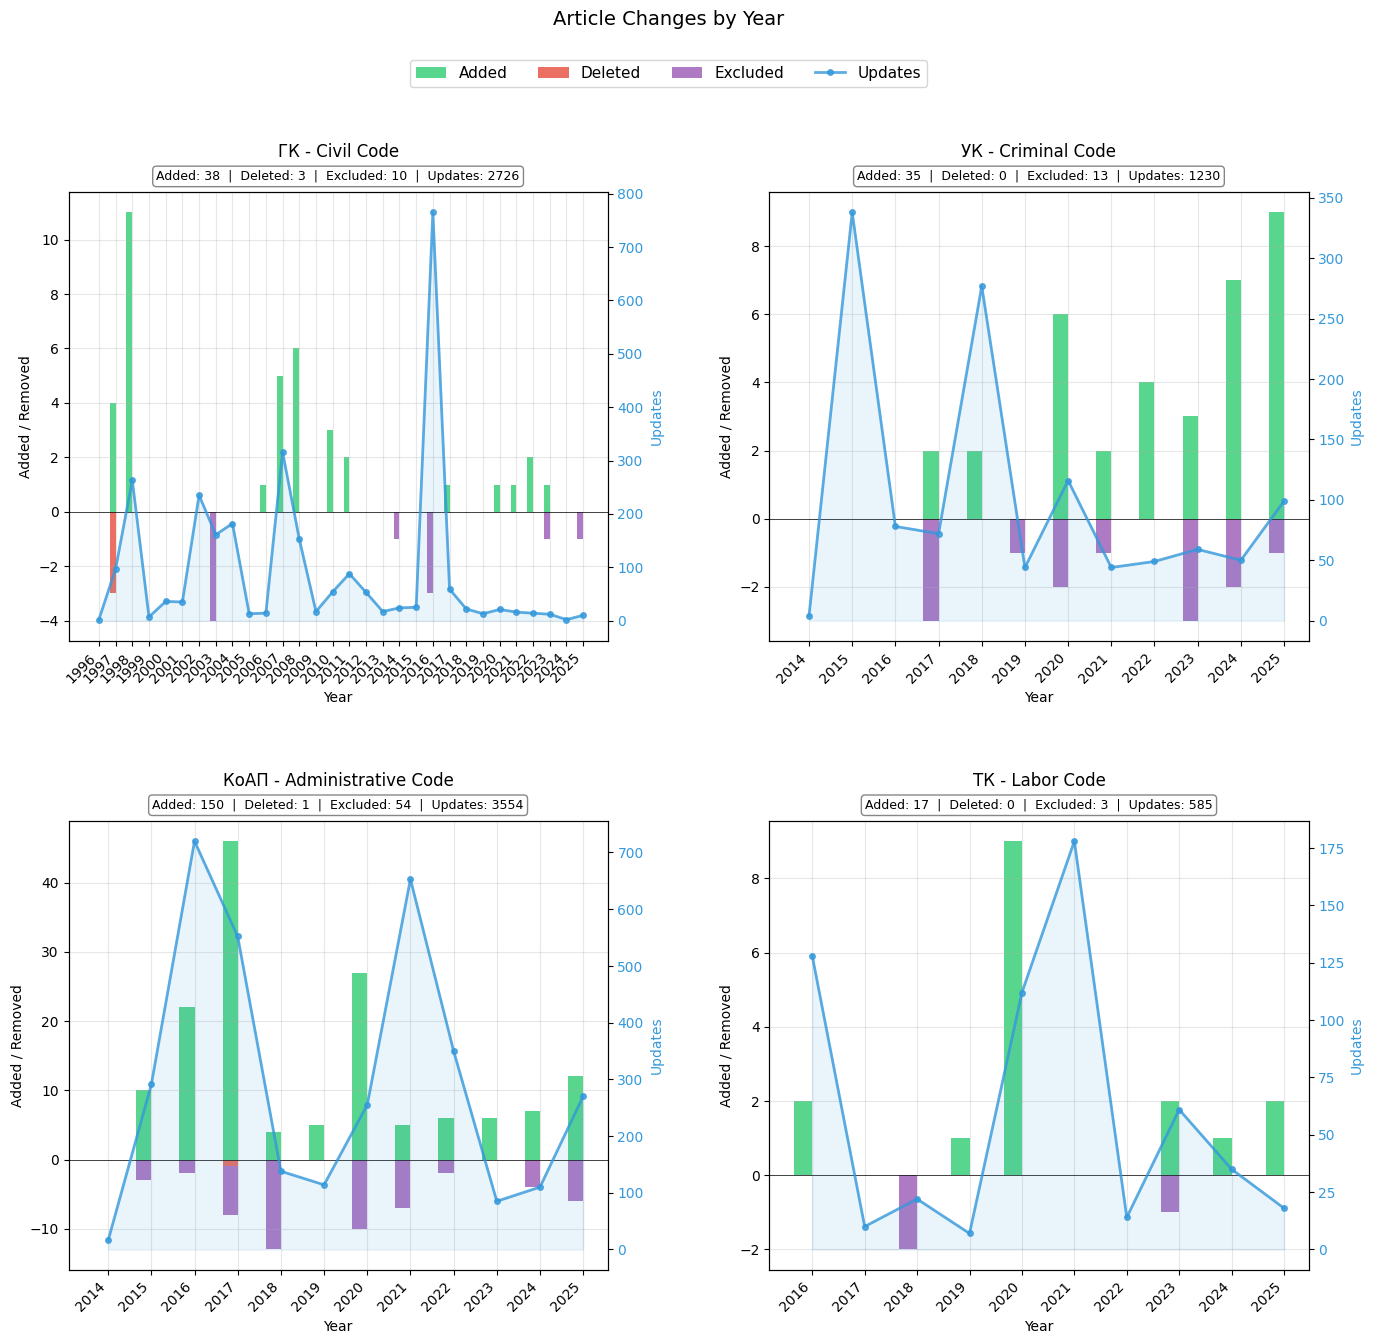

In [50]:
# Article additions, deletions, exclusions and updates by year
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Add vertical padding between subplots
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Store handles and labels for shared legend
legend_handles = []
legend_labels = []

for idx, code_key in enumerate(['civil', 'criminal', 'administrative', 'labor']):
    ax = axes[idx // 2, idx % 2]
    code_events = events_df[events_df['code_key'] == code_key]
    code_info = CODES[code_key]
    
    # Exclude initial and initial_excluded - only show changes AFTER first version
    yearly = code_events[~code_events['event'].isin(['initial', 'initial_excluded'])].groupby(['year', 'event']).size().unstack(fill_value=0)
    
    # Bar width for grouped bars
    width = 0.35
    years = yearly.index
    x = np.arange(len(years))
    
    # Calculate totals for annotation (excludes initial articles)
    total_added = yearly['added'].sum() if 'added' in yearly.columns else 0
    total_deleted = yearly['deleted'].sum() if 'deleted' in yearly.columns else 0
    total_excluded = yearly['excluded'].sum() if 'excluded' in yearly.columns else 0
    total_updated = yearly['updated'].sum() if 'updated' in yearly.columns else 0
    
    # Count initial articles separately
    initial_count = len(code_events[code_events['event'].isin(['initial', 'initial_excluded'])])
    
    # Plot additions as positive bars
    bar_added = None
    if 'added' in yearly.columns:
        bar_added = ax.bar(x - width/2, yearly['added'], width, color='#2ecc71', alpha=0.8)
    
    # Plot deleted and excluded as stacked negative bars
    deleted_vals = yearly['deleted'] if 'deleted' in yearly.columns else 0
    excluded_vals = yearly['excluded'] if 'excluded' in yearly.columns else 0
    
    bar_deleted = ax.bar(x - width/2, -deleted_vals, width, color='#e74c3c', alpha=0.8)
    bar_excluded = ax.bar(x - width/2, -excluded_vals, width, bottom=-deleted_vals, color='#9b59b6', alpha=0.8)
    
    # Plot updates as a line on secondary y-axis
    ax2 = ax.twinx()
    line_updated = None
    if 'updated' in yearly.columns:
        line_updated, = ax2.plot(x, yearly['updated'], color='#3498db', linewidth=2, marker='o', 
                 markersize=4, alpha=0.8)
        ax2.fill_between(x, yearly['updated'], alpha=0.1, color='#3498db')
        ax2.set_ylabel('Updates', color='#3498db', fontsize=10)
        ax2.tick_params(axis='y', labelcolor='#3498db')
    
    # Collect legend handles from first subplot only
    if idx == 0:
        if bar_added is not None:
            legend_handles.append(bar_added)
            legend_labels.append('Added')
        legend_handles.append(bar_deleted)
        legend_labels.append('Deleted')
        legend_handles.append(bar_excluded)
        legend_labels.append('Excluded')
        if line_updated is not None:
            legend_handles.append(line_updated)
            legend_labels.append('Updates')
    
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Year')
    ax.set_ylabel('Added / Removed')
    
    # Title: Code name (larger font, no box)
    ax.set_title(f"{code_info['short']} - {code_info['name_en']}", fontsize=12, pad=25)
    
    # Totals in rectangle below title (shows initial count separately)
    totals_text = f"Added: {total_added}  |  Deleted: {total_deleted}  |  Excluded: {total_excluded}  |  Updates: {total_updated}"
    ax.annotate(totals_text, xy=(0.5, 1.02), xycoords='axes fraction',
                ha='center', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.95))
    
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)

# Add shared legend at the top
fig.legend(legend_handles, legend_labels, loc='upper center', ncol=4, 
           bbox_to_anchor=(0.5, 0.98), fontsize=11, frameon=True)

plt.suptitle('Article Changes by Year', fontsize=14, y=1.01)
plt.savefig(OUTPUT_DIR / "article_changes_by_year.png", dpi=150, bbox_inches='tight')
plt.show()

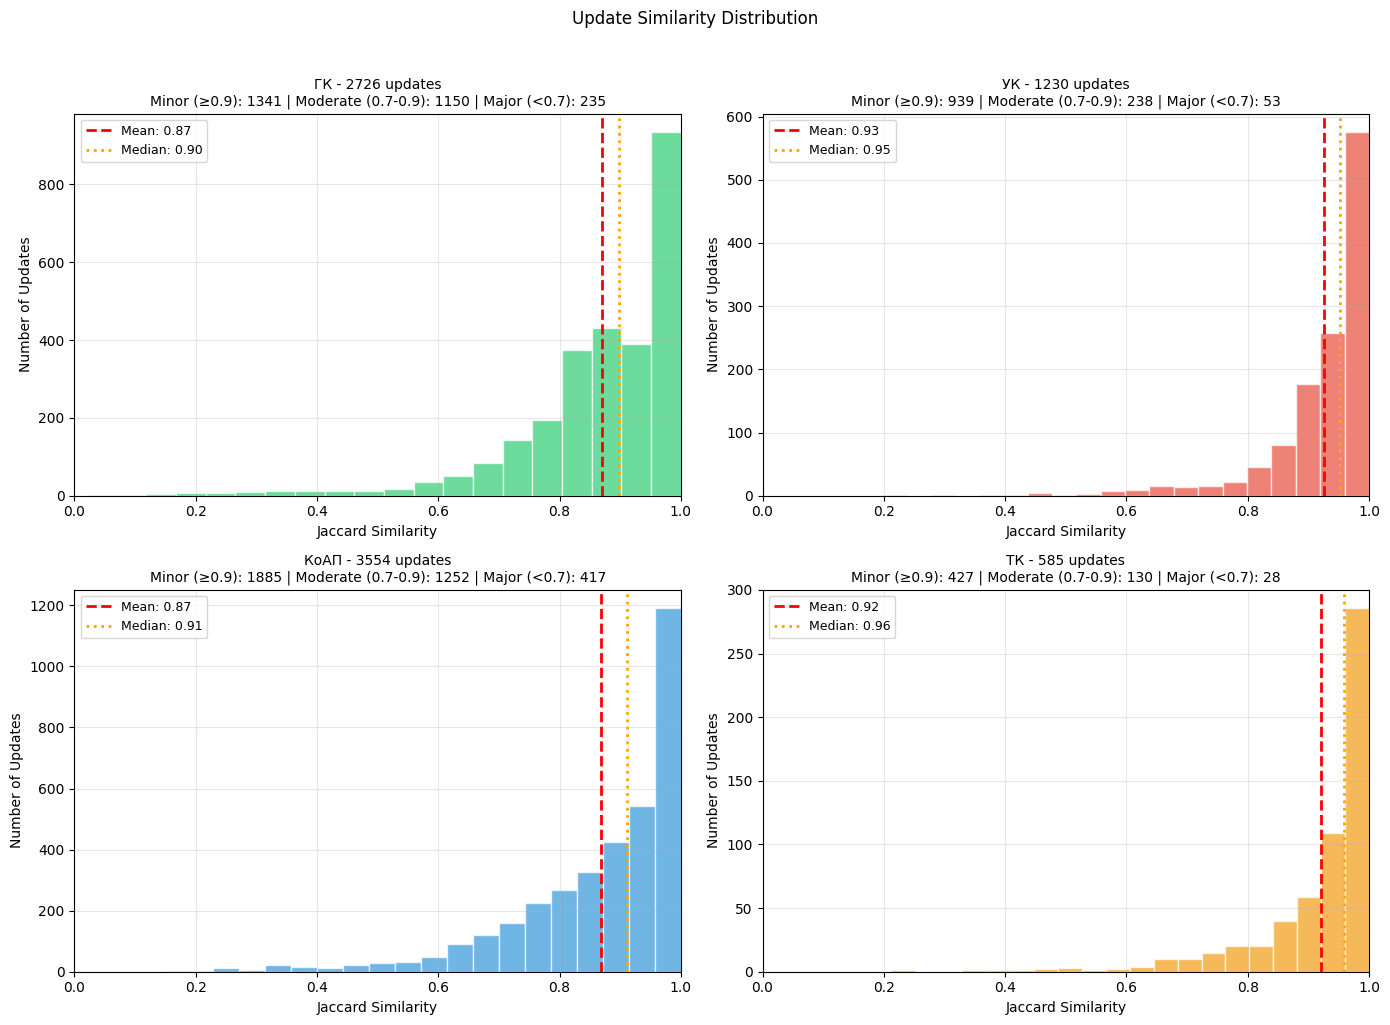

In [51]:
# Update similarity distribution - shows magnitude of changes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, code_key in enumerate(['civil', 'criminal', 'administrative', 'labor']):
    ax = axes[idx // 2, idx % 2]
    code_updates = events_df[(events_df['code_key'] == code_key) & (events_df['event'] == 'updated')]
    code_info = CODES[code_key]
    
    if len(code_updates) > 0:
        # Histogram of similarity scores
        ax.hist(code_updates['similarity'], bins=20, alpha=0.7, color=code_info['color'], edgecolor='white')
        
        # Add vertical lines for mean and median
        mean_sim = code_updates['similarity'].mean()
        median_sim = code_updates['similarity'].median()
        ax.axvline(mean_sim, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_sim:.2f}')
        ax.axvline(median_sim, color='orange', linestyle=':', linewidth=2, label=f'Median: {median_sim:.2f}')
        
        # Categorize updates
        minor = (code_updates['similarity'] >= 0.9).sum()
        moderate = ((code_updates['similarity'] >= 0.7) & (code_updates['similarity'] < 0.9)).sum()
        major = (code_updates['similarity'] < 0.7).sum()
        
        ax.set_xlabel('Jaccard Similarity', fontsize=10)
        ax.set_ylabel('Number of Updates', fontsize=10)
        ax.set_title(f"{code_info['short']} - {len(code_updates)} updates\n"
                     f"Minor (≥0.9): {minor} | Moderate (0.7-0.9): {moderate} | Major (<0.7): {major}", 
                     fontsize=10)
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1)
    else:
        ax.text(0.5, 0.5, 'No updates', ha='center', va='center', fontsize=12)
        ax.set_title(f"{code_info['short']} - {code_info['name_en']}")
    
    ax.grid(True, alpha=0.3)

plt.suptitle('Update Similarity Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "update_similarity_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

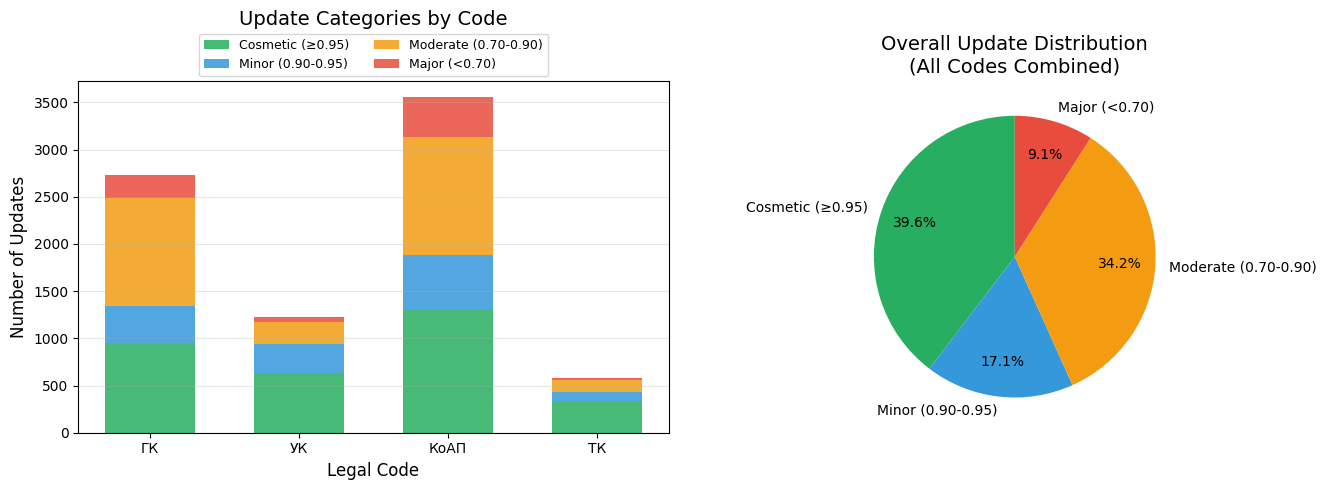


UPDATE CATEGORY BREAKDOWN:
Code         Cosmetic        Minor     Moderate        Major      Total
--------------------------------------------------------------------------------
ГК                951          390         1150          235       2726
УК                635          304          238           53       1230
КоАП             1301          584         1252          417       3554
ТК                322          105          130           28        585
--------------------------------------------------------------------------------
TOTAL            3209         1383         2770          733       8095

Interpretation:
- Cosmetic: Punctuation, formatting, minor wording changes
- Minor: Small substantive changes, clarifications
- Moderate: Significant edits to provisions
- Major: Complete rewrites, structural changes



In [52]:
# Categorize updates by magnitude and visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define update categories
def categorize_update(similarity):
    if similarity >= 0.95:
        return 'Cosmetic (≥0.95)'
    elif similarity >= 0.90:
        return 'Minor (0.90-0.95)'
    elif similarity >= 0.70:
        return 'Moderate (0.70-0.90)'
    else:
        return 'Major (<0.70)'

update_events = events_df[events_df['event'] == 'updated'].copy()
update_events['category'] = update_events['similarity'].apply(categorize_update)

# Left: Stacked bar chart by code
ax1 = axes[0]
category_order = ['Cosmetic (≥0.95)', 'Minor (0.90-0.95)', 'Moderate (0.70-0.90)', 'Major (<0.70)']
category_colors = ['#27ae60', '#3498db', '#f39c12', '#e74c3c']

category_counts = update_events.groupby(['code_key', 'category']).size().unstack(fill_value=0)
category_counts = category_counts[category_order]

codes = ['civil', 'criminal', 'administrative', 'labor']
code_names = [CODES[c]['short'] for c in codes]
x = np.arange(len(codes))
width = 0.6

bottom = np.zeros(len(codes))
for cat, color in zip(category_order, category_colors):
    values = [category_counts.loc[c, cat] if c in category_counts.index else 0 for c in codes]
    ax1.bar(x, values, width, label=cat, bottom=bottom, color=color, alpha=0.85)
    bottom += values

ax1.set_xlabel('Legal Code', fontsize=12)
ax1.set_ylabel('Number of Updates', fontsize=12)
ax1.set_title('Update Categories by Code', fontsize=14, pad=40)  # Add padding for legend
ax1.set_xticks(x)
ax1.set_xticklabels(code_names)
# Place legend at top, below title
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Right: Pie chart showing overall distribution
ax2 = axes[1]
overall_counts = update_events['category'].value_counts()[category_order]
wedges, texts, autotexts = ax2.pie(overall_counts, labels=category_order, colors=category_colors,
                                    autopct='%1.1f%%', startangle=90, pctdistance=0.75)
ax2.set_title('Overall Update Distribution\n(All Codes Combined)', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'update_categories.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\nUPDATE CATEGORY BREAKDOWN:")
print("=" * 80)
print(f"{'Code':<8} {'Cosmetic':>12} {'Minor':>12} {'Moderate':>12} {'Major':>12} {'Total':>10}")
print("-" * 80)

for code_key in codes:
    code_short = CODES[code_key]['short']
    counts = [category_counts.loc[code_key, cat] if code_key in category_counts.index else 0 for cat in category_order]
    total = sum(counts)
    print(f"{code_short:<8} {counts[0]:>12} {counts[1]:>12} {counts[2]:>12} {counts[3]:>12} {total:>10}")

totals = [overall_counts[cat] for cat in category_order]
print("-" * 80)
print(f"{'TOTAL':<8} {totals[0]:>12} {totals[1]:>12} {totals[2]:>12} {totals[3]:>12} {sum(totals):>10}")

print("""
Interpretation:
- Cosmetic: Punctuation, formatting, minor wording changes
- Minor: Small substantive changes, clarifications
- Moderate: Significant edits to provisions
- Major: Complete rewrites, structural changes
""")

In [53]:
# Show examples of major rewrites (lowest similarity)
print("Examples of MAJOR REWRITES (lowest similarity):")
print("-" * 80)
for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_updates = events_df[(events_df['code_key'] == code_key) & (events_df['event'] == 'updated')]
    code_info = CODES[code_key]
    
    if len(code_updates) > 0:
        major_rewrites = code_updates.nsmallest(20, 'similarity')
        print(f"\n{code_info['short']}:")
        for _, row in major_rewrites.iterrows():
            print(f"  Ст.{row['article_number']:6} | sim={row['similarity']:.2f} | {row['date'].strftime('%Y-%m-%d')} | {row['article_title'][:90]}...")

Examples of MAJOR REWRITES (lowest similarity):
--------------------------------------------------------------------------------

ГК:
  Ст.90     | sim=0.02 | 1998-07-10 | Статья 90. Уменьшение объявленного и выпущенного (оплаченного) уставного капитала...
  Ст.54     | sim=0.10 | 1997-01-21 | Статья 54. Реабилитационная процедура по делам о банкротстве...
  Ст.82     | sim=0.12 | 1998-03-22 | Статья 82. Принудительный выкуп доли у участника товарищества...
  Ст.91     | sim=0.13 | 1998-07-10 | Статья 91. Выпуск и размещение ценных бумаг...
  Ст.88     | sim=0.14 | 2003-05-16 | Статья 88. Уставный капитал акционерного общества...
  Ст.53     | sim=0.14 | 1997-01-21 | Статья 53. Признание банкротства...
  Ст.280    | sim=0.15 | 1997-07-11 | Статья 280. Информация о ходе исполнения обязательства...
  Ст.129    | sim=0.19 | 2003-05-16 | Статья 129. Ценные бумаги...
  Ст.206    | sim=0.20 | 2011-03-01 | Статья 206. Распоряжение имуществом учреждения...
  Ст.130    | sim=0.20 | 2003-05-16 |

In [54]:
# Deep dive: Before/After text comparison for major rewrites
print("=" * 80)
print("BEFORE/AFTER COMPARISON FOR MAJOR REWRITES")
print("=" * 80)

# Get major rewrites from different time periods
update_events = events_df[
    (events_df['event'] == 'updated') & 
    (events_df['similarity'] < 0.35)
].copy()
update_events['date'] = pd.to_datetime(update_events['date'])

# Get samples from different periods: pre-2010, 2010-2020, post-2020
periods = [
    ('Pre-2010', update_events[update_events['date'] < '2010-01-01'].nsmallest(2, 'similarity')),
    ('2010-2020', update_events[(update_events['date'] >= '2010-01-01') & (update_events['date'] < '2020-01-01')].nsmallest(2, 'similarity')),
    ('Post-2020', update_events[update_events['date'] >= '2020-01-01'].nsmallest(2, 'similarity'))
]

print(f"\nShowing major rewrites across different time periods:\n")

idx = 0
for period_name, period_data in periods:
    if len(period_data) == 0:
        print(f"\n{period_name}: No major rewrites found")
        continue
        
    print(f"\n{'#'*80}")
    print(f"### {period_name} ###")
    print(f"{'#'*80}")
    
    for _, row in period_data.iterrows():
        idx += 1
        code_key = row['code_key']
        article_num = row['article_number']
        version_num = row['version_number']
        similarity = row['similarity']
        date = row['date']
        
        code_info = CODES[code_key]
        version_idx = all_indices[code_key]
        
        # Find the version file for before/after
        versions = version_idx['versions']
        current_ver = None
        prev_ver = None
        
        for v in versions:
            if v['version_number'] == version_num:
                current_ver = v
                break
            prev_ver = v
        
        if not current_ver or not prev_ver:
            continue
        
        # Load both versions
        try:
            current_data = load_version_file(code_info['folder'], current_ver['filename'])
            prev_data = load_version_file(code_info['folder'], prev_ver['filename'])
            
            # Find article in both versions by article number
            current_article = None
            prev_article = None
            
            for art in current_data.get('articles', []):
                title = art.get('article_title', '')
                if f'Статья {article_num}.' in title or f'Статья {article_num} ' in title:
                    current_article = art
                    break
            
            for art in prev_data.get('articles', []):
                title = art.get('article_title', '')
                if f'Статья {article_num}.' in title or f'Статья {article_num} ' in title:
                    prev_article = art
                    break
            
            if current_article and prev_article:
                date_str = date.strftime('%Y-%m-%d') if hasattr(date, 'strftime') else str(date)[:10]
                print(f"\n{'='*80}")
                print(f"#{idx}. {code_info['short']} Ст.{article_num} | Similarity: {similarity:.2f} | Date: {date_str}")
                print(f"{'='*80}")
                
                prev_text = prev_article.get('article_text', '')[:400]
                curr_text = current_article.get('article_text', '')[:400]
                
                print(f"\nBEFORE (v{version_num-1}, {prev_ver['version_date']}):")
                print("-" * 40)
                print(prev_text + ("..." if len(prev_article.get('article_text', '')) > 400 else ""))
                
                print(f"\nAFTER (v{version_num}, {current_ver['version_date']}):")
                print("-" * 40)
                print(curr_text + ("..." if len(current_article.get('article_text', '')) > 400 else ""))
                
        except Exception as e:
            print(f"Could not load versions for {code_info['short']} article {article_num}: {e}")

print(f"\n\n{'='*80}")
print("INSIGHT: These major rewrites often indicate:")
print("- Complete restructuring of legal provisions")
print("- Adoption of new regulatory frameworks")
print("- Harmonization with international standards")
print("- Response to significant economic/political changes")
print("="*80)

BEFORE/AFTER COMPARISON FOR MAJOR REWRITES

Showing major rewrites across different time periods:


################################################################################
### Pre-2010 ###
################################################################################

#1. ГК Ст.90 | Similarity: 0.02 | Date: 1998-07-10

BEFORE (v10, 29.06.1998):
----------------------------------------
1. Акционерное общество вправе по решению общего собрания акционеров уменьшить, но не менее минимального размера, предусмотренного законодательными актами, уставный капитал путем уменьшения номинальной стоимости акций, либо путем покупки части акций в целях их аннулирования. N 211 Z980211_ .

AFTER (v11, 10.07.1998):
----------------------------------------
Уменьшение объявленного и выпущенного (оплаченного) уставного капитала акционерного общества производится в порядке, установленном законодательством.

#2. ГК Ст.54 | Similarity: 0.10 | Date: 1997-01-21

BEFORE (v2, 07.12.1996):
-------------

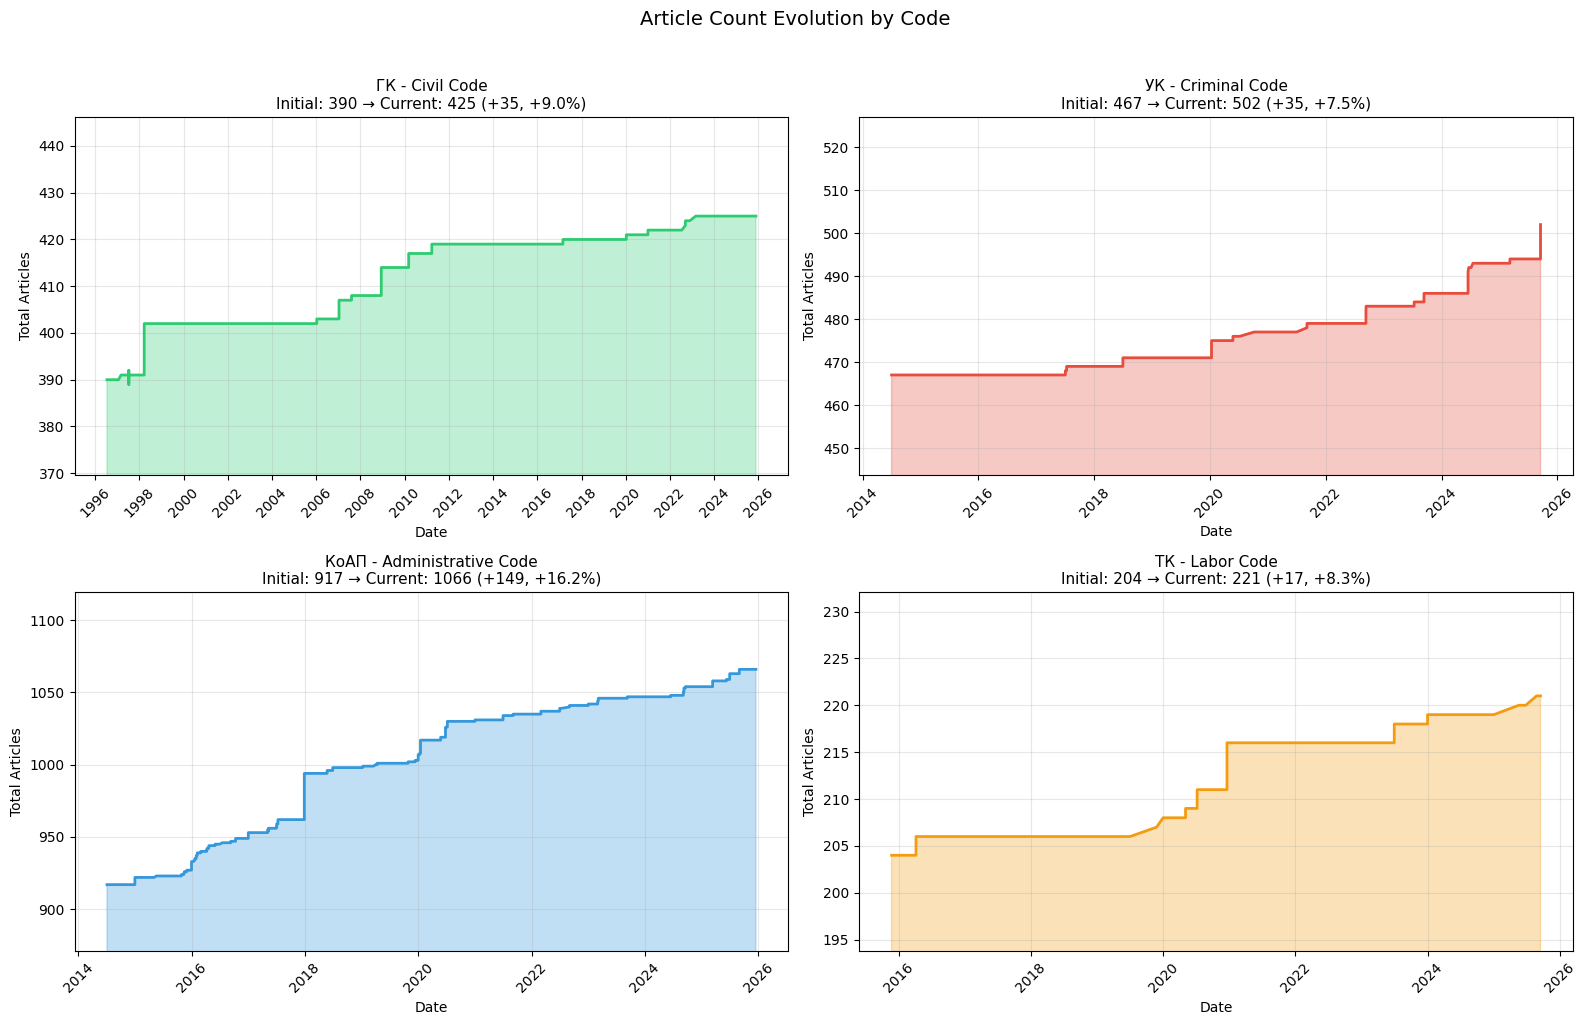


Article Count Changes Summary:
------------------------------------------------------------
ГК     |  390 initial →  425 current (+9.0%) | +38 added, -3 deleted
УК     |  467 initial →  502 current (+7.5%) | +35 added, -0 deleted
КоАП   |  917 initial → 1066 current (+16.2%) | +150 added, -1 deleted
ТК     |  204 initial →  221 current (+8.3%) | +17 added, -0 deleted


In [55]:
# Article count growth over time (normalized to show % change from initial)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, code_key in enumerate(['civil', 'criminal', 'administrative', 'labor']):
    ax = axes[idx // 2, idx % 2]
    code_events = events_df[events_df['code_key'] == code_key].sort_values('date')
    code_info = CODES[code_key]
    
    if len(code_events) == 0:
        ax.set_title(f"{code_info['short']} - {code_info['name_en']}\nNo data available", fontsize=11)
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Get initial count first
    initial_count = len(code_events[code_events['event'] == 'initial'])
    
    # Handle edge case where initial_count is 0
    if initial_count == 0:
        initial_count = 1  # fallback
    
    # Calculate cumulative count starting from initial_count
    # 'initial' events are already counted, only 'added' and 'deleted' change the count
    code_events = code_events.copy()
    code_events['delta'] = code_events['event'].map({'initial': 0, 'added': 1, 'deleted': -1, 'updated': 0}).fillna(0)
    code_events['cumulative'] = initial_count + code_events['delta'].cumsum()
    
    # Plot absolute count on primary y-axis
    ax.fill_between(code_events['date'], code_events['cumulative'], 
                    alpha=0.3, color=code_info['color'])
    ax.plot(code_events['date'], code_events['cumulative'], 
            color=code_info['color'], linewidth=2, label='Article count')
    
    # Get final count safely
    final_count = int(code_events['cumulative'].iloc[-1])
    net_change = final_count - initial_count
    
    # Calculate percentage change safely
    if initial_count > 0:
        pct_change = (net_change / initial_count) * 100
        pct_str = f"{pct_change:+.1f}%"
    else:
        pct_str = "N/A"
    
    change_sign = '+' if net_change >= 0 else ''
    
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Total Articles', fontsize=10)
    ax.set_title(f"{code_info['short']} - {code_info['name_en']}\n"
                 f"Initial: {initial_count} → Current: {final_count} ({change_sign}{net_change}, {pct_str})", 
                 fontsize=11)
    
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # Set y-axis to start from a reasonable minimum (90% of min value)
    y_min = code_events['cumulative'].min() * 0.95
    y_max = code_events['cumulative'].max() * 1.05
    ax.set_ylim(y_min, y_max)

plt.suptitle('Article Count Evolution by Code', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "article_count_evolution.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nArticle Count Changes Summary:")
print("-" * 60)
for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_events = events_df[events_df['code_key'] == code_key]
    code_info = CODES[code_key]
    
    initial = len(code_events[code_events['event'] == 'initial'])
    added = len(code_events[code_events['event'] == 'added'])
    deleted = len(code_events[code_events['event'] == 'deleted'])
    current = initial + added - deleted
    
    if initial > 0:
        pct = ((current - initial) / initial) * 100
        pct_str = f"{pct:+.1f}%"
    else:
        pct_str = "N/A"
    
    print(f"{code_info['short']:6} | {initial:4} initial → {current:4} current ({pct_str}) | +{added} added, -{deleted} deleted")

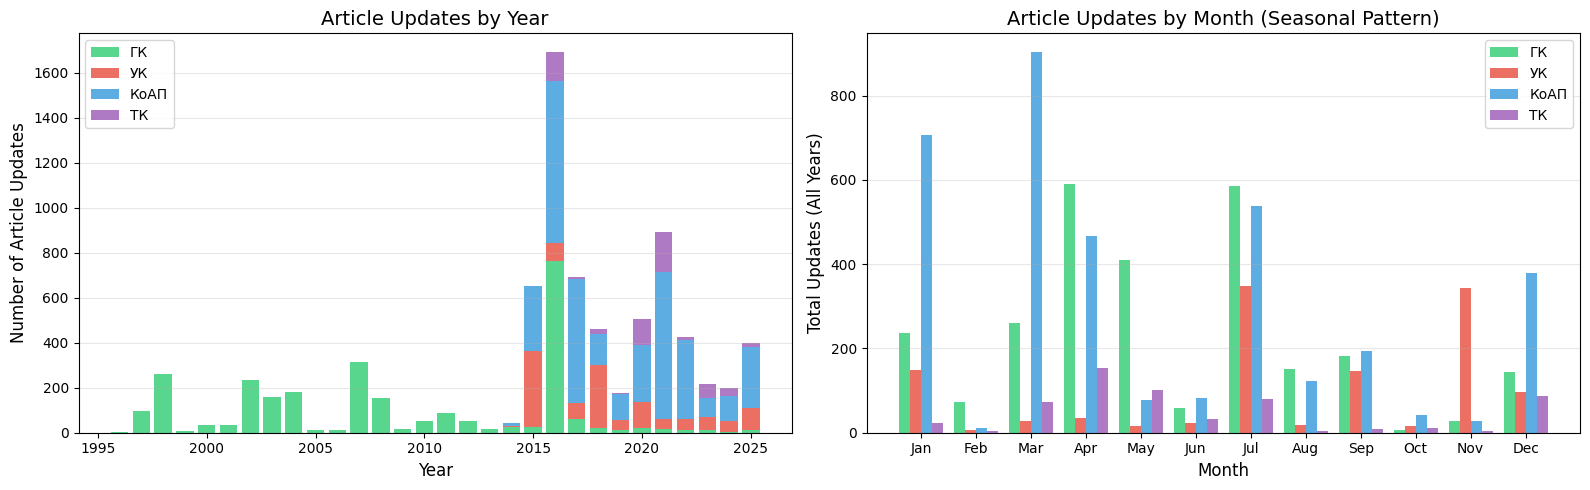


PEAK UPDATE ACTIVITY:
------------------------------------------------------------
Most active year: 2016 (1691 updates)
Most active month: Jul (1554 updates across all years)


In [56]:
# Update activity by year and month - when do most changes happen?
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Prepare data
update_events = events_df[events_df['event'] == 'updated'].copy()
update_events['date'] = pd.to_datetime(update_events['date'])
update_events['year'] = update_events['date'].dt.year
update_events['month'] = update_events['date'].dt.month

# Left: Updates by year for each code
ax1 = axes[0]
yearly_updates = update_events.groupby(['year', 'code_key']).size().unstack(fill_value=0)

colors = {'civil': '#2ecc71', 'criminal': '#e74c3c', 'administrative': '#3498db', 'labor': '#9b59b6'}
bottom = np.zeros(len(yearly_updates))

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    if code_key in yearly_updates.columns:
        ax1.bar(yearly_updates.index, yearly_updates[code_key], bottom=bottom, 
                label=CODES[code_key]['short'], color=colors[code_key], alpha=0.8)
        bottom += yearly_updates[code_key].values

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Article Updates', fontsize=12)
ax1.set_title('Article Updates by Year', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# Right: Updates by month (aggregate across all years)
ax2 = axes[1]
monthly_updates = update_events.groupby(['month', 'code_key']).size().unstack(fill_value=0)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(12) + 1
width = 0.2

for i, code_key in enumerate(['civil', 'criminal', 'administrative', 'labor']):
    if code_key in monthly_updates.columns:
        values = [monthly_updates.loc[m, code_key] if m in monthly_updates.index else 0 for m in range(1, 13)]
        ax2.bar(x + i*width - 1.5*width, values, width, 
                label=CODES[code_key]['short'], color=colors[code_key], alpha=0.8)

ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Total Updates (All Years)', fontsize=12)
ax2.set_title('Article Updates by Month (Seasonal Pattern)', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(month_names)
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'update_activity_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\nPEAK UPDATE ACTIVITY:")
print("-" * 60)
peak_year = yearly_updates.sum(axis=1).idxmax()
peak_month = monthly_updates.sum(axis=1).idxmax()
print(f"Most active year: {peak_year} ({yearly_updates.sum(axis=1).max()} updates)")
print(f"Most active month: {month_names[peak_month-1]} ({monthly_updates.sum(axis=1).max()} updates across all years)")

## 7. Identify Most Stable and Volatile Articles

In [57]:
# Most stable articles (present in all versions, longest lifespan)
print("MOST STABLE ARTICLES (Present Since Beginning, Never Deleted)")
print("=" * 80)

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_df = lifespans_df[lifespans_df['code_key'] == code_key]
    code_info = CODES[code_key]
    total_versions = all_indices[code_key]['total_versions']
    
    # Get max versions_present to understand actual available data
    max_versions_present = code_df['versions_present'].max() if len(code_df) > 0 else 0
    
    # Use max_versions_present as the effective total (accounts for missing version files)
    effective_total = max_versions_present if max_versions_present < total_versions else total_versions
    
    # Articles present in all available versions
    most_stable = code_df[
        (code_df['versions_present'] == effective_total) & 
        (~code_df['was_deleted'])
    ].sort_values('lifespan_years', ascending=False)
    
    # Show info about missing versions if any
    if effective_total < total_versions:
        missing = total_versions - effective_total
        print(f"\n{code_info['short']} - {len(most_stable)} articles present in all {effective_total} available versions ({missing} version files missing):")
    else:
        print(f"\n{code_info['short']} - {len(most_stable)} articles present in all {total_versions} versions:")
    
    if len(most_stable) > 0:
        for _, row in most_stable.head(10).iterrows():
            print(f"  Ст.{row['article_number']:<6} | {row['versions_present']:3} versions | {row['lifespan_years']:.1f} years | {row['article_title']}")
    else:
        print(f"  No stable articles found.")

MOST STABLE ARTICLES (Present Since Beginning, Never Deleted)

ГК - 387 articles present in all 179 versions:
  Ст.43     | 179 versions | 29.3 years | Статья 43. Филиалы, представительства и иные обособленные структурные подразделения юридического лица
  Ст.170    | 179 versions | 29.3 years | Статья 170. Прекращение доверенности
  Ст.377    | 179 versions | 29.3 years | Статья 377. Прекращение обязательства ликвидацией юридического лица
  Ст.309    | 179 versions | 29.3 years | Статья 309. Имущество, на которое распространяются права залогодержателя
  Ст.263    | 179 versions | 29.3 years | Статья 263. Расчеты при возврате вещей из незаконного владения
  Ст.97     | 179 versions | 29.3 years | Статья 97. Устав производственного кооператива
  Ст.254    | 179 versions | 29.3 years | Статья 254. Конфискация
  Ст.307    | 179 versions | 29.3 years | Статья 307. Содержание и форма договора о залоге
  Ст.82     | 179 versions | 29.3 years | Статья 82. Принудительный выкуп доли у участника 

In [58]:
lifespans_df[lifespans_df['was_deleted']]

,code_key,code_short,article_number,article_title,first_seen,last_seen,versions_present,was_deleted,is_excluded,exclusion_date,exclusion_reason,update_count,total_change_magnitude,avg_change_per_update,lifespan_days,lifespan_years


In [59]:
# Deleted articles (completely removed from the code)
print("DELETED ARTICLES (Completely Removed from Code)")
print("=" * 80)

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_info = CODES[code_key]
    
    # Get deleted events directly from events_df
    code_events = events_df[events_df['code_key'] == code_key]
    deleted_events = code_events[code_events['event'] == 'deleted'].sort_values('date', ascending=False)
    
    print(f"\n{code_info['short']} - {len(deleted_events)} deleted articles:")
    
    if len(deleted_events) > 0:
        for _, row in deleted_events.iterrows():
            art_num = row['article_number']
            version_num = row['version_number']
            del_date = row['date'].strftime('%Y-%m-%d')
            title = row['article_title'][:60] + '...' if len(str(row['article_title'])) > 60 else row['article_title']
            print(f"  Ст.{art_num:<6} | Deleted: v{version_num}, {del_date} | {title}")
    else:
        print("  No deleted articles found.")

DELETED ARTICLES (Completely Removed from Code)

ГК - 3 deleted articles:
  Ст.140    | Deleted: v7, 1997-07-11 | Статья 140. Банковский сертификат
  Ст.137    | Deleted: v7, 1997-07-11 | Статья 137. Чек
  Ст.138    | Deleted: v7, 1997-07-11 | Статья 138. Вексель

УК - 0 deleted articles:
  No deleted articles found.

КоАП - 1 deleted articles:
  Ст.460-1  | Deleted: v65, 2017-05-10 | Статья 460-1. Нарушение порядка представления сведений о пол...

ТК - 0 deleted articles:
  No deleted articles found.


In [60]:
# Recently added articles
print("RECENTLY ADDED ARTICLES (Added in Last 3 Years)")
print("=" * 80)

recent_cutoff = datetime.now() - pd.Timedelta(days=3*365)

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_events = events_df[
        (events_df['code_key'] == code_key) & 
        (events_df['event'] == 'added') &
        (events_df['date'] > recent_cutoff)
    ].sort_values('date', ascending=False)
    
    code_info = CODES[code_key]
    
    print(f"\n{code_info['short']} - {len(code_events)} articles added since {recent_cutoff.strftime('%Y-%m-%d')}:")
    for _, row in code_events.head(10).iterrows():
        print(f"  {row['date'].strftime('%Y-%m-%d')} | Ст.{row['article_number']:6} | {row['article_title']}")

RECENTLY ADDED ARTICLES (Added in Last 3 Years)

ГК - 1 articles added since 2023-01-13:
  2023-03-03 | Ст.20-1   | Статья 20-1. Восстановление платежеспособности и банкротство гражданина Республики Казахстан

УК - 19 articles added since 2023-01-13:
  2025-09-16 | Ст.232-1  | Статья 232-1. Незаконное предоставление, передача и приобретение доступа к банковскому счету, платежному инструменту или идентификационному средству, а также незаконное осуществление платежей и (или) переводов денег
  2025-09-16 | Ст.352-1  | Статья 352-1. Создание помех управлению воздушным судном
  2025-09-16 | Ст.214-1  | Статья 214-1. Незаконная банковская, микрофинансовая деятельность
  2025-09-16 | Ст.214-2  | Статья 214-2. Незаконная коллекторская деятельность
  2025-09-16 | Ст.125-1  | Статья 125-1. Принуждение к вступлению в брак
  2025-09-16 | Ст.115-1  | Статья 115-1. Сталкинг
  2025-09-16 | Ст.339-1  | Статья 339-1. Незаконное обращение с частями или дериватами редких и находящихся под угрозой исчезно

In [61]:
# Recently excluded articles (last 3 years) - indicates current policy shifts
print("RECENTLY EXCLUDED ARTICLES (Excluded in Last 3 Years)")
print("=" * 80)

cutoff_date = pd.Timestamp.now() - pd.DateOffset(years=3)

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_info = CODES[code_key]
    code_events = events_df[
        (events_df['code_key'] == code_key) & 
        (events_df['event'] == 'excluded')
    ].copy()
    
    code_events['date'] = pd.to_datetime(code_events['date'])
    recent = code_events[code_events['date'] >= cutoff_date].sort_values('date', ascending=False)
    
    print(f"\n{code_info['short']} - {len(recent)} articles excluded since {cutoff_date.strftime('%Y-%m-%d')}:")
    
    if len(recent) == 0:
        print("  No recent exclusions")
    else:
        for _, row in recent.head(10).iterrows():
            date_str = row['date'].strftime('%Y-%m-%d')
            article_num = row['article_number']
            details = row.get('deletion_reason', '')[:80] if row.get('deletion_reason') else ''
            print(f"  {date_str} | Ст.{article_num:<8} | {details}...")

print("\n" + "=" * 80)
print("INSIGHT: Recent exclusions may indicate:")
print("- Obsolete regulations being phased out")
print("- Consolidation of legal provisions")  
print("- Response to economic/technological changes")
print("- Alignment with new legislation")
print("=" * 80)

RECENTLY EXCLUDED ARTICLES (Excluded in Last 3 Years)

ГК - 2 articles excluded since 2023-01-12:
  2025-11-20 | Ст.262      | Сноска. Статью 262 исключена Законом РК от 19.09.2025 № 219-VIII (вводится в дей...
  2023-03-03 | Ст.56       | Сноска. Статья 56 исключена Законом РК от 30.12.2022 № 179-VII (вводится в дейст...

УК - 6 articles excluded since 2023-01-12:
  2025-09-16 | Ст.197      | Сноска. Статья 197 исключена Законом РК от 16.07.2025 № 210-VIII (вводится в дей...
  2024-09-05 | Ст.241      | Сноска. Статья 241 исключена Законом РК от 05.07.2024 № 113-VIII (вводится в дей...
  2024-09-05 | Ст.219      | Сноска. Статья 219 исключена Законом РК от 05.07.2024 № 113-VIII (вводится в дей...
  2023-07-12 | Ст.373      | Сноска. Статья 373 исключена Законом РК от 12.07.2023 № 23-VIII (вводится в дейс...
  2023-07-12 | Ст.235      | Сноска. Статья 235 исключена Законом РК от 12.07.2023 № 23-VIII (вводится в дейс...
  2023-07-12 | Ст.374      | Сноска. Статья 374 исключена Законом Р

In [62]:
# Most frequently updated articles (with change magnitude)
print("MOST FREQUENTLY UPDATED ARTICLES")
print("=" * 80)

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_df = lifespans_df[lifespans_df['code_key'] == code_key]
    code_info = CODES[code_key]
    
    most_updated = code_df[code_df['update_count'] > 0].sort_values('update_count', ascending=False)
    total_updates = most_updated['update_count'].sum()
    total_magnitude = most_updated['total_change_magnitude'].sum()
    
    print(f"\n{code_info['short']} - {total_updates} updates (total change magnitude: {total_magnitude:.1f}):")
    print(f"  {'Article':<8} | {'Updates':>7} | {'Magnitude':>9} | {'Avg/Update':>10} | Title")
    print(f"  {'-'*8} | {'-'*7} | {'-'*9} | {'-'*10} | {'-'*40}")
    for _, row in most_updated.head(10).iterrows():
        print(f"  Ст.{row['article_number']:<5} | {row['update_count']:>7} | {row['total_change_magnitude']:>9.2f} | {row['avg_change_per_update']:>10.3f} | {row['article_title'][:80]}...")

# Most changed articles by magnitude (not just count)
print("\n" + "=" * 80)
print("MOST CHANGED ARTICLES (by total change magnitude)")
print("=" * 80)

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_df = lifespans_df[lifespans_df['code_key'] == code_key]
    code_info = CODES[code_key]
    
    most_changed = code_df[code_df['total_change_magnitude'] > 0].sort_values('total_change_magnitude', ascending=False)
    
    print(f"\n{code_info['short']} - Top 5 by change magnitude:")
    for _, row in most_changed.head(5).iterrows():
        print(f"  Ст.{row['article_number']:<5} | magnitude={row['total_change_magnitude']:.2f} | {row['update_count']} updates | {row['article_title'][:80]}...")

MOST FREQUENTLY UPDATED ARTICLES

ГК - 2726 updates (total change magnitude: 352.7):
  Article  | Updates | Magnitude | Avg/Update | Title
  -------- | ------- | --------- | ---------- | ----------------------------------------
  Ст.49    |      33 |      2.84 |      0.086 | Статья 49. Основания ликвидации юридического лица...
  Ст.50    |      30 |      2.05 |      0.068 | Статья 50. Порядок ликвидации юридического лица...
  Ст.59    |      30 |      2.47 |      0.082 | Статья 59. Вклад в уставный капитал хозяйственного товарищества. Доля участника ...
  Ст.45    |      28 |      2.25 |      0.080 | Статья 45. Реорганизация юридического лица...
  Ст.42    |      25 |      2.76 |      0.110 | Статья 42. Государственная регистрация и перерегистрация юридических лиц...
  Ст.328   |      25 |      3.00 |      0.120 | Статья 328. Залог вещей в ломбарде...
  Ст.41    |      24 |      1.77 |      0.074 | Статья 41. Учредительные документы юридического лица...
  Ст.51    |      22 |      1.38

## 8. Lifespan Distribution Analysis

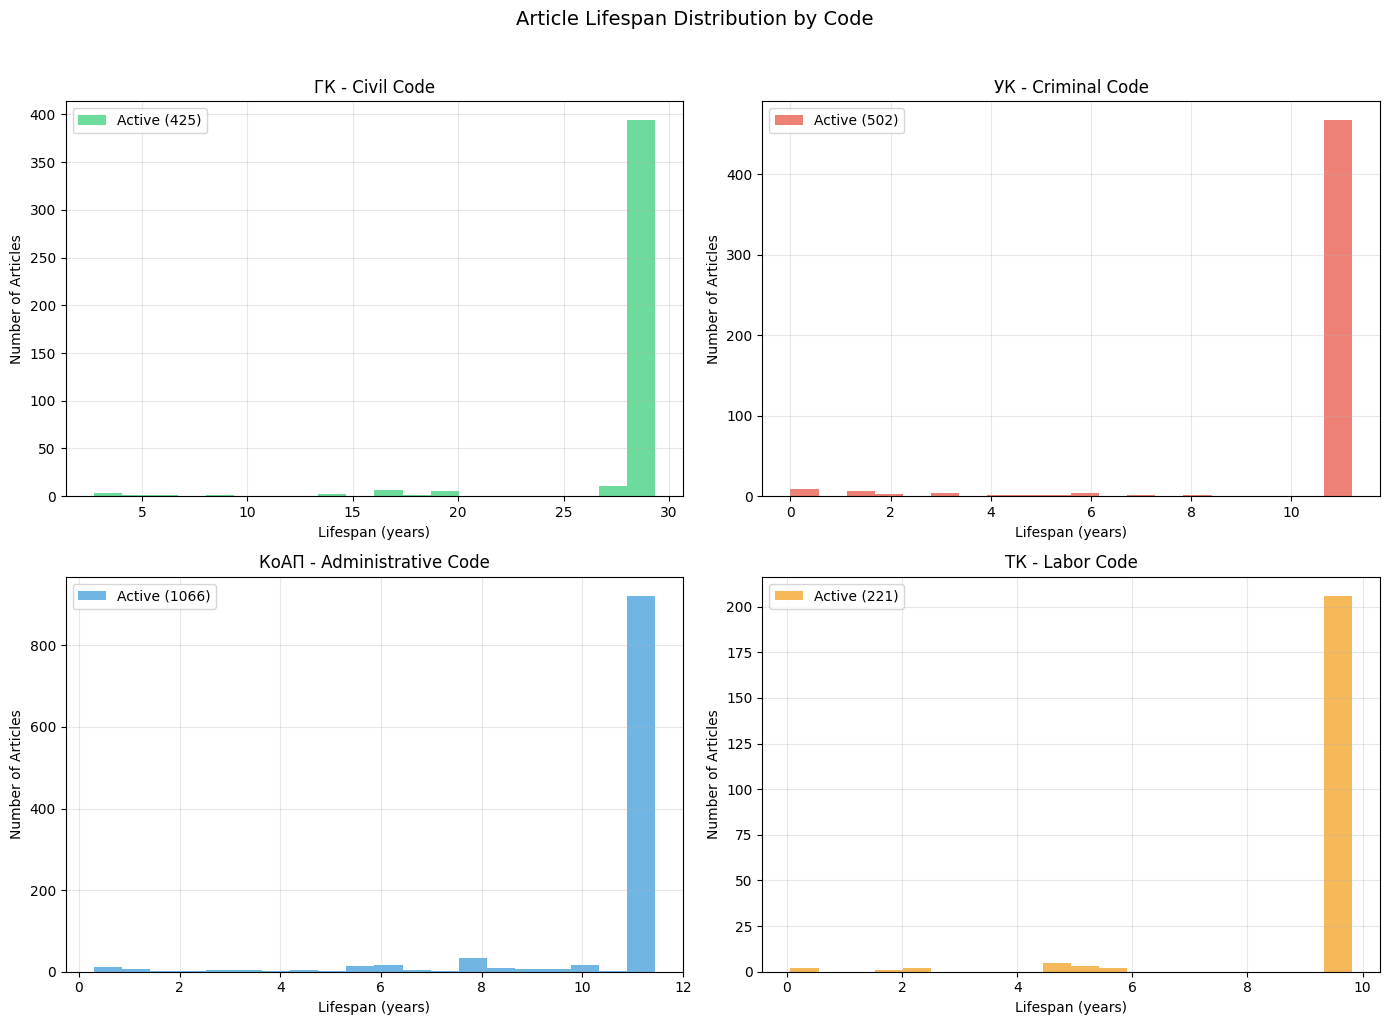

In [63]:
# Lifespan distribution by code
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, code_key in enumerate(['civil', 'criminal', 'administrative', 'labor']):
    ax = axes[idx // 2, idx % 2]
    code_df = lifespans_df[lifespans_df['code_key'] == code_key]
    code_info = CODES[code_key]
    
    # Separate active and deleted
    active = code_df[~code_df['was_deleted']]['lifespan_years']
    deleted = code_df[code_df['was_deleted']]['lifespan_years']
    
    if len(active) > 0:
        ax.hist(active, bins=20, alpha=0.7, label=f'Active ({len(active)})', color=code_info['color'])
    if len(deleted) > 0:
        ax.hist(deleted, bins=20, alpha=0.7, label=f'Deleted ({len(deleted)})', color='#95a5a6')
    
    ax.set_xlabel('Lifespan (years)')
    ax.set_ylabel('Number of Articles')
    ax.set_title(f"{code_info['short']} - {code_info['name_en']}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Article Lifespan Distribution by Code', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lifespan_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# Stability metrics comparison
stability_metrics = []

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_df = lifespans_df[lifespans_df['code_key'] == code_key]
    code_events = events_df[events_df['code_key'] == code_key]
    code_info = CODES[code_key]
    total_versions = all_indices[code_key]['total_versions']
    
    n_initial = len(code_events[code_events['event'] == 'initial'])
    n_added = len(code_events[code_events['event'] == 'added'])
    n_deleted = len(code_events[code_events['event'] == 'deleted'])
    
    # Articles present in all versions
    n_all_versions = len(code_df[code_df['versions_present'] == total_versions])
    
    # Turnover rate
    turnover_rate = (n_added + n_deleted) / n_initial * 100 if n_initial > 0 else 0
    
    # Stability rate (articles never deleted / total unique)
    stability_rate = len(code_df[~code_df['was_deleted']]) / len(code_df) * 100
    
    stability_metrics.append({
        'code_key': code_key,
        'code_short': code_info['short'],
        'total_versions': total_versions,
        'initial_articles': n_initial,
        'articles_added': n_added,
        'articles_deleted': n_deleted,
        'unique_articles': len(code_df),
        'present_all_versions': n_all_versions,
        'turnover_rate': turnover_rate,
        'stability_rate': stability_rate,
        'avg_lifespan_years': code_df['lifespan_years'].mean()
    })

stability_df = pd.DataFrame(stability_metrics)
print("Stability Metrics Comparison:")
stability_df

Stability Metrics Comparison:


,code_key,code_short,total_versions,initial_articles,articles_added,articles_deleted,unique_articles,present_all_versions,turnover_rate,stability_rate,avg_lifespan_years
0,civil,ГК,179,390,38,3,425,387,10.512821,100.0,28.559185
1,criminal,УК,109,467,35,0,502,467,7.494647,100.0,10.622556
2,administrative,КоАП,205,917,150,1,1066,917,16.466739,100.0,10.770821
3,labor,ТК,69,204,17,0,221,204,8.333333,100.0,9.405855


In [65]:
# Clarify stability metrics and add more meaningful churn rates
print("=" * 80)
print("UNDERSTANDING THE STABILITY METRICS")
print("=" * 80)

print("""
NOTE: The 'stability_rate' shows ~100% for all codes because very few articles 
are actually DELETED (only 4 total). Most articles that become inactive are 
EXCLUDED (marked as void but kept in the document with empty content).

More meaningful metrics:
""")

# Calculate better metrics
print("CHURN METRICS (accounts for both deletions and exclusions):")
print("-" * 80)
print(f"{'Code':<8} {'Deleted':>10} {'Excluded':>10} {'Churn Rate':>12} {'Effective Loss':>15}")
print("-" * 80)

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_events = events_df[events_df['code_key'] == code_key]
    code_info = CODES[code_key]
    
    n_initial = len(code_events[code_events['event'] == 'initial'])
    n_deleted = len(code_events[code_events['event'] == 'deleted'])
    n_excluded = len(code_events[code_events['event'] == 'excluded'])
    n_added = len(code_events[code_events['event'] == 'added'])
    
    # Churn rate = (deleted + excluded) / (initial + added) * 100
    total_articles = n_initial + n_added
    churn_rate = (n_deleted + n_excluded) / total_articles * 100 if total_articles > 0 else 0
    
    # Effective loss = (deleted + excluded - added) / initial * 100 (negative means net growth)
    effective_loss = (n_deleted + n_excluded - n_added) / n_initial * 100 if n_initial > 0 else 0
    
    loss_str = f"{effective_loss:+.1f}%" if effective_loss != 0 else "0.0%"
    
    print(f"{code_info['short']:<8} {n_deleted:>10} {n_excluded:>10} {churn_rate:>11.1f}% {loss_str:>15}")

print("-" * 80)
print("""
Interpretation:
- Churn Rate: % of articles that were removed (deleted or excluded) from active use
- Effective Loss: Net change accounting for additions (negative = net growth)
- КоАП has highest churn but also highest additions, resulting in net growth
- ГК has lowest churn rate, indicating most stable legislative structure
""")

UNDERSTANDING THE STABILITY METRICS

NOTE: The 'stability_rate' shows ~100% for all codes because very few articles 
are actually DELETED (only 4 total). Most articles that become inactive are 
EXCLUDED (marked as void but kept in the document with empty content).

More meaningful metrics:

CHURN METRICS (accounts for both deletions and exclusions):
--------------------------------------------------------------------------------
Code        Deleted   Excluded   Churn Rate  Effective Loss
--------------------------------------------------------------------------------
ГК                3         10         3.0%           -6.4%
УК                0         13         2.6%           -4.7%
КоАП              1         54         5.2%          -10.4%
ТК                0          3         1.4%           -6.9%
--------------------------------------------------------------------------------

Interpretation:
- Churn Rate: % of articles that were removed (deleted or excluded) from active use
- Ef

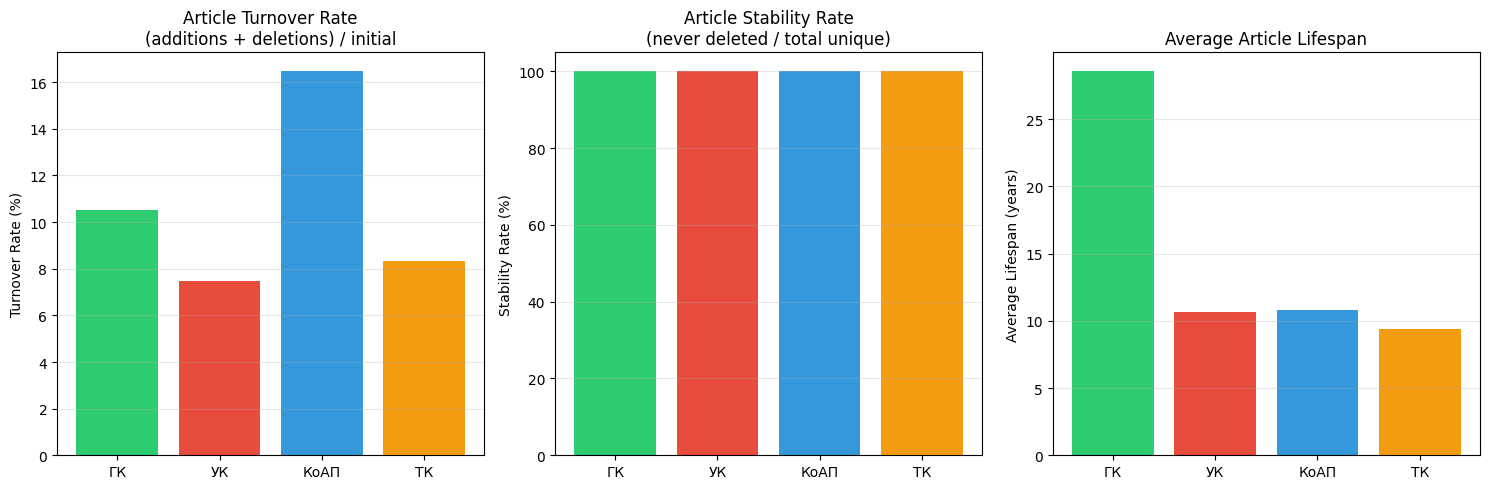

In [66]:
# Visualize stability metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

codes = stability_df['code_short'].tolist()
colors = [CODES[k]['color'] for k in stability_df['code_key']]

# Turnover rate
axes[0].bar(codes, stability_df['turnover_rate'], color=colors)
axes[0].set_ylabel('Turnover Rate (%)')
axes[0].set_title('Article Turnover Rate\n(additions + deletions) / initial')
axes[0].grid(True, alpha=0.3, axis='y')

# Stability rate
axes[1].bar(codes, stability_df['stability_rate'], color=colors)
axes[1].set_ylabel('Stability Rate (%)')
axes[1].set_title('Article Stability Rate\n(never deleted / total unique)')
axes[1].grid(True, alpha=0.3, axis='y')

# Average lifespan
axes[2].bar(codes, stability_df['avg_lifespan_years'], color=colors)
axes[2].set_ylabel('Average Lifespan (years)')
axes[2].set_title('Average Article Lifespan')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stability_metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Export Results

In [67]:
# Export lifecycle events
events_export = events_df.copy()
events_export['date_str'] = events_export['date'].dt.strftime('%Y-%m-%d')
events_export[['code_key', 'code_short', 'date_str', 'event', 'article_number', 'article_title', 'version_number']].to_csv(
    OUTPUT_DIR / 'article_lifecycle_events.csv', index=False
)
print(f"Exported {len(events_export)} lifecycle events to article_lifecycle_events.csv")

# Export lifespans
lifespans_export = lifespans_df.copy()
lifespans_export['first_seen_str'] = lifespans_export['first_seen'].dt.strftime('%Y-%m-%d')
lifespans_export['last_seen_str'] = lifespans_export['last_seen'].dt.strftime('%Y-%m-%d')
lifespans_export[['code_key', 'code_short', 'article_number', 'article_title', 'first_seen_str', 'last_seen_str', 
                  'versions_present', 'was_deleted', 'update_count', 'lifespan_days', 'lifespan_years']].to_csv(
    OUTPUT_DIR / 'article_lifespans.csv', index=False
)
print(f"Exported {len(lifespans_export)} article lifespans to article_lifespans.csv")

# Export stability metrics
stability_df.to_csv(OUTPUT_DIR / 'stability_metrics.csv', index=False)
print(f"Exported stability metrics to stability_metrics.csv")

Exported 10397 lifecycle events to article_lifecycle_events.csv
Exported 2214 article lifespans to article_lifespans.csv
Exported stability metrics to stability_metrics.csv


## 10. Summary

In [68]:
print("=" * 80)
print("KEY FINDINGS - Article Lifecycle Analysis")
print("=" * 80)

total_events = len(events_df)
unique_articles = len(lifespans_df)

print(f"""
1. DATA SCOPE
   {'─'*70}
   Total lifecycle events tracked: {total_events:,}
   Unique articles analyzed: {unique_articles:,}

   Events breakdown:
   - Initial (first version): {len(events_df[events_df['event'] == 'initial']):,}
   - Added over time: {len(events_df[events_df['event'] == 'added']):,}
   - Deleted (completely removed): {len(events_df[events_df['event'] == 'deleted']):,}
   - Excluded (by law, void content): {len(events_df[events_df['event'] == 'excluded']):,}
   - Updated (text changed): {len(events_df[events_df['event'] == 'updated']):,}

2. ARTICLE COUNT CHANGES
   {'─'*70}""")

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_info = CODES[code_key]
    code_events = events_df[events_df['code_key'] == code_key]
    code_lifespans = lifespans_df[lifespans_df['code_key'] == code_key]
    
    n_initial = len(code_events[code_events['event'] == 'initial'])
    n_added = len(code_events[code_events['event'] == 'added'])
    n_deleted = len(code_events[code_events['event'] == 'deleted'])
    n_excluded = len(code_events[code_events['event'] == 'excluded'])
    n_current = len(code_lifespans)
    growth = (n_current - n_initial) / n_initial * 100 if n_initial > 0 else 0
    
    print(f"   {code_info['short']:<5}: {n_initial:>4} → {n_current:>4} ({growth:+.1f}%) | +{n_added} added, -{n_deleted} deleted, {n_excluded} excluded")

print(f"""
3. UPDATE INTENSITY
   {'─'*70}""")

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_info = CODES[code_key]
    code_updates = events_df[(events_df['code_key'] == code_key) & (events_df['event'] == 'updated')]
    mean_sim = code_updates['similarity'].mean() if len(code_updates) > 0 else 0
    print(f"   {code_info['short']:<5}: {len(code_updates):>5} updates | Mean similarity: {mean_sim:.3f}")

print(f"""
4. MOST UPDATED ARTICLES (across all codes)
   {'─'*70}""")

most_updated = lifespans_df.nlargest(5, 'update_count')
for _, row in most_updated.iterrows():
    title = row['article_title'][:50] + '...' if len(row['article_title']) > 50 else row['article_title']
    print(f"   {row['code_short']:<5} Ст.{row['article_number']:<6} | {row['update_count']:>3} updates | {title}")

print(f"""
5. STABILITY METRICS
   {'─'*70}""")

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_info = CODES[code_key]
    code_lifespans = lifespans_df[lifespans_df['code_key'] == code_key]
    avg_lifespan = code_lifespans['lifespan_years'].mean()
    avg_updates = code_lifespans['update_count'].mean()
    no_updates = len(code_lifespans[code_lifespans['update_count'] == 0])
    print(f"   {code_info['short']:<5}: Avg lifespan {avg_lifespan:.1f} years | Avg updates {avg_updates:.1f} | {no_updates} never updated")

print(f"""
6. DELETED & EXCLUDED ARTICLES
   {'─'*70}""")

for code_key in ['civil', 'criminal', 'administrative', 'labor']:
    code_info = CODES[code_key]
    code_events = events_df[events_df['code_key'] == code_key]
    deleted = code_events[code_events['event'] == 'deleted']
    excluded = code_events[code_events['event'] == 'excluded']
    
    del_arts = ', '.join([f"Ст.{a}" for a in deleted['article_number'].values[:3]])
    if len(deleted) > 3:
        del_arts += f" +{len(deleted)-3} more"
    
    print(f"   {code_info['short']:<5}: {len(deleted)} deleted, {len(excluded)} excluded" + 
          (f" - {del_arts}" if len(deleted) > 0 else ""))

print(f"""
7. UPDATE CATEGORIES (by change magnitude)
   {'─'*70}""")

updates = events_df[events_df['event'] == 'updated']
cosmetic = len(updates[updates['similarity'] >= 0.95])
minor = len(updates[(updates['similarity'] >= 0.90) & (updates['similarity'] < 0.95)])
moderate = len(updates[(updates['similarity'] >= 0.70) & (updates['similarity'] < 0.90)])
major = len(updates[updates['similarity'] < 0.70])

print(f"   Cosmetic (≥0.95):    {cosmetic:>5} ({cosmetic/len(updates)*100:.1f}%)")
print(f"   Minor (0.90-0.95):   {minor:>5} ({minor/len(updates)*100:.1f}%)")
print(f"   Moderate (0.70-0.90):{moderate:>5} ({moderate/len(updates)*100:.1f}%)")
print(f"   Major (<0.70):       {major:>5} ({major/len(updates)*100:.1f}%)")

print(f"""
{'='*80}
CONCLUSIONS:
- КоАП (Administrative) shows highest growth (+16.2%) and update frequency
- ГК (Civil) has longest article lifespans (~29 years) but moderate updates
- УК (Criminal) has most stable text (highest mean similarity 0.926)
- Most updates are cosmetic/minor; major rewrites are rare (<10%)
- Very few articles are deleted; exclusion (by law) is preferred
{'='*80}
""")

KEY FINDINGS - Article Lifecycle Analysis

1. DATA SCOPE
   ──────────────────────────────────────────────────────────────────────
   Total lifecycle events tracked: 10,397
   Unique articles analyzed: 2,214

   Events breakdown:
   - Initial (first version): 1,978
   - Added over time: 240
   - Deleted (completely removed): 4
   - Excluded (by law, void content): 80
   - Updated (text changed): 8,095

2. ARTICLE COUNT CHANGES
   ──────────────────────────────────────────────────────────────────────
   ГК   :  390 →  425 (+9.0%) | +38 added, -3 deleted, 10 excluded
   УК   :  467 →  502 (+7.5%) | +35 added, -0 deleted, 13 excluded
   КоАП :  917 → 1066 (+16.2%) | +150 added, -1 deleted, 54 excluded
   ТК   :  204 →  221 (+8.3%) | +17 added, -0 deleted, 3 excluded

3. UPDATE INTENSITY
   ──────────────────────────────────────────────────────────────────────
   ГК   :  2726 updates | Mean similarity: 0.871
   УК   :  1230 updates | Mean similarity: 0.926
   КоАП :  3554 updates | Mean si